# 0. IMPORTAR LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import seaborn as sns
import locale
import datetime
from datetime import datetime, date
import calendar
import os
import warnings

from scipy import stats
from scipy.stats import norm, chi2, cauchy, chi2_contingency, f_oneway, kruskal, kendalltau, pearsonr, spearmanr, median_abs_deviation
import scipy.stats as sps
import numpy.linalg as la

from sklearn.decomposition import NMF, PCA, FactorAnalysis, TruncatedSVD
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelBinarizer, OneHotEncoder, LabelEncoder, KBinsDiscretizer
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, f_regression, mutual_info_regression
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import accuracy_score, mutual_info_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_regression, make_classification
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt


from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
from factor_analyzer import FactorAnalyzer
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from itertools import combinations
import semopy
import prince

%matplotlib inline
sns.set_theme()
pd.set_option('display.max_columns', None)

warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. IMPORTAR Y LIMPIEZA DEL DATASET

## 1.1. IMPORTACIÓN, RENOMBRE, FILTRADO Y CLASIFICACIÓN

In [2]:
df = pd.read_csv('secop_2024.csv')

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Sector,Rama,Entidad Centralizada,Estado Contrato,Tipo de Contrato,Modalidad de Contratacion,Fecha de Firma,Fecha de Inicio del Contrato,Fecha de Fin del Contrato,Es Grupo,Es Pyme,Habilita Pago Adelantado,Liquidación,Obligación Ambiental,Obligaciones Postconsumo,Valor del Contrato,Valor Pendiente de Pago,Valor Pagado,Valor Amortizado,Valor Pendiente de Ejecucion,Estado BPIN,Saldo CDP,EsPostConflicto,Recursos de Credito,Recursos Propios,El contrato puede ser prorrogado
0,Transporte,Corporación Autónoma,Descentralizada,Cerrado,Prestación de servicios,Contratación directa,2024-03-19,03/19/2024,04/30/2024,No,No,No,No,No,No,$14.000.000,$14.000.000,$0,$0,$14.000.000,Válido,$0,No,$0,$0,No
1,Servicio Público,Ejecutivo,Centralizada,Aprobado,Prestación de servicios,Contratación directa,2024-09-11,NaN,12/31/2024,No,No,No,No,No,No,$13.200.000,$13.200.000,$0,$0,$13.200.000,Válido,$0,No,$0,$0,No
2,Salud y Protección Social,Ejecutivo,Descentralizada,Modificado,Prestación de servicios,Contratación régimen especial,2024-12-11,12/11/2024,10/31/2025,No,No,No,No,No,No,$74.604.735,$74.604.735,$0,$0,$74.604.735,No Válido,$0,No,$0,$74.604.735,Si
3,agricultura,Ejecutivo,Centralizada,En ejecución,Prestación de servicios,Contratación directa,2024-11-19,11/27/2024,12/31/2024,No,No,No,No,No,No,$10.000.000,$10.000.000,$0,$0,$10.000.000,Válido,$0,No,$0,$0,No
4,Servicio Público,Ejecutivo,Descentralizada,terminado,Prestación de servicios,Contratación directa,2024-02-12,02/14/2024,08/13/2024,No,No,No,No,No,No,$16.200.000,$0,$16.200.000,$0,$0,Válido,$16.200.000,No,$0,$0,No


### 1.1.1 FILTRAR VARIABLES

In [4]:
#Eliminar Columnas que no utilizaremos
eliminarcolumns = ['Estado Contrato','Valor Pendiente de Pago','Valor Pagado','Valor Amortizado', 'Valor Pendiente de Ejecucion', 'Saldo CDP','Recursos de Credito',
       'Recursos Propios']

In [5]:
df = df.drop(columns=eliminarcolumns)

df.head()

,Sector,Rama,Entidad Centralizada,Tipo de Contrato,Modalidad de Contratacion,Fecha de Firma,Fecha de Inicio del Contrato,Fecha de Fin del Contrato,Es Grupo,Es Pyme,Habilita Pago Adelantado,Liquidación,Obligación Ambiental,Obligaciones Postconsumo,Valor del Contrato,Estado BPIN,EsPostConflicto,El contrato puede ser prorrogado
0,Transporte,Corporación Autónoma,Descentralizada,Prestación de servicios,Contratación directa,2024-03-19,03/19/2024,04/30/2024,No,No,No,No,No,No,$14.000.000,Válido,No,No
1,Servicio Público,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-09-11,NaN,12/31/2024,No,No,No,No,No,No,$13.200.000,Válido,No,No
2,Salud y Protección Social,Ejecutivo,Descentralizada,Prestación de servicios,Contratación régimen especial,2024-12-11,12/11/2024,10/31/2025,No,No,No,No,No,No,$74.604.735,No Válido,No,Si
3,agricultura,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-11-19,11/27/2024,12/31/2024,No,No,No,No,No,No,$10.000.000,Válido,No,No
4,Servicio Público,Ejecutivo,Descentralizada,Prestación de servicios,Contratación directa,2024-02-12,02/14/2024,08/13/2024,No,No,No,No,No,No,$16.200.000,Válido,No,No


In [6]:
df.Sector.value_counts()

Sector
Servicio Público                                      233425
No aplica/No pertenece                                148881
Salud y Protección Social                             138658
Educación Nacional                                     48598
Trabajo                                                42221
deportes                                               35646
Ambiente y Desarrollo Sostenible                       34599
Información Estadística                                27089
defensa                                                26931
Transporte                                             25765
Cultura                                                25052
agricultura                                            24626
Inclusión Social y Reconciliación                      23154
Vivienda, Ciudad y Territorio                          14309
Ley de Justicia                                        13336
Planeación                                             10762
Hacienda y Crédit

### 1.1.2 RENOMBRAR VARIABLES

In [7]:
df.columns

Index(['Sector', 'Rama', 'Entidad Centralizada', 'Tipo de Contrato',
       'Modalidad de Contratacion', 'Fecha de Firma',
       'Fecha de Inicio del Contrato', 'Fecha de Fin del Contrato', 'Es Grupo',
       'Es Pyme', 'Habilita Pago Adelantado', 'Liquidación',
       'Obligación Ambiental', 'Obligaciones Postconsumo',
       'Valor del Contrato', 'Estado BPIN', 'EsPostConflicto',
       'El contrato puede ser prorrogado'],
      dtype='str')

In [8]:
df.columns = ['sector','rama','centralizada','tipo_contrato','modalidad_contratacion','fecha_firma','fecha_inicio','fecha_fin','grupo','pime','pago_adelantado','liquidacion','obligacion_ambiente','obligacion_postconsumo','valor_contrato','estado_bpin','postconflicto','prorrogado']

### 1.1.3 CALCULAR VARIABLES

In [9]:
fechas = [
    "fecha_firma",
    "fecha_inicio",
    "fecha_fin"
]

for col in fechas:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [10]:
df["dias_espera_inicio"] = (df["fecha_inicio"] - df["fecha_firma"]).dt.days
df["duracion_contrato"] = (df["fecha_fin"] - df["fecha_inicio"]).dt.days
fecha_inicio_min = df["fecha_inicio"].min()
df["dias_desde_primer_contrato"] = (df["fecha_inicio"] - fecha_inicio_min).dt.days#Cuántos días después del primer contrato del dataset inicia cada contrato.
df = df[(df["duracion_contrato"] >= 0) &(df["dias_espera_inicio"] >= 0)]
df["dias_espera_inicio"] = df["dias_espera_inicio"].astype(int)
df["duracion_contrato"] = df["duracion_contrato"].astype(int)
df["dias_desde_primer_contrato"] = df["dias_desde_primer_contrato"].astype(int)
df

,sector,rama,centralizada,tipo_contrato,modalidad_contratacion,fecha_firma,fecha_inicio,fecha_fin,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,valor_contrato,estado_bpin,postconflicto,prorrogado,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato
0,Transporte,Corporación Autónoma,Descentralizada,Prestación de servicios,Contratación directa,2024-03-19,2024-03-19,2024-04-30,No,No,No,No,No,No,$14.000.000,Válido,No,No,0,42,2854
2,Salud y Protección Social,Ejecutivo,Descentralizada,Prestación de servicios,Contratación régimen especial,2024-12-11,2024-12-11,2025-10-31,No,No,No,No,No,No,$74.604.735,No Válido,No,Si,0,324,3121
3,agricultura,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-11-19,2024-11-27,2024-12-31,No,No,No,No,No,No,$10.000.000,Válido,No,No,8,34,3107
4,Servicio Público,Ejecutivo,Descentralizada,Prestación de servicios,Contratación directa,2024-02-12,2024-02-14,2024-08-13,No,No,No,No,No,No,$16.200.000,Válido,No,No,2,181,2820
5,Salud y Protección Social,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-10-01,2024-10-05,2024-12-31,No,No,No,No,No,No,$13.639.878,No Válido,No,No,4,87,3054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915637,No aplica/No pertenece,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-02-15,2024-02-15,2024-07-14,No,No,No,No,No,No,$8.000.000,Válido,No,No,0,150,2821
915638,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-01-17,2024-01-17,2024-12-31,No,No,No,No,No,No,$46.290.268,No Válido,No,No,0,349,2792
915639,Servicio Público,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,2024-09-14,2024-09-17,2024-09-30,No,No,No,No,No,No,$3.280.000,Válido,No,No,3,13,3036
915640,Servicio Público,Ejecutivo,Centralizada,Otro,Selección Abreviada de Menor Cuantía,2024-12-13,2024-12-17,2025-07-30,No,Si,No,No,No,No,$46.873.884,Válido,No,No,4,225,3127


### 1.1.4 CONVERTIR VARIABLES


In [11]:
df["valor_contratoo"] = (df["valor_contrato"].str.replace("$", "", regex=False).str.replace(".", "", regex=False).str.strip()).astype(int)

In [12]:
eliminarcolumns = ['fecha_inicio','fecha_firma','fecha_fin','valor_contrato',]
df = df.drop(columns=eliminarcolumns)


df

,sector,rama,centralizada,tipo_contrato,modalidad_contratacion,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,postconflicto,prorrogado,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
0,Transporte,Corporación Autónoma,Descentralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No,0,42,2854,14000000
2,Salud y Protección Social,Ejecutivo,Descentralizada,Prestación de servicios,Contratación régimen especial,No,No,No,No,No,No,No Válido,No,Si,0,324,3121,74604735
3,agricultura,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No,8,34,3107,10000000
4,Servicio Público,Ejecutivo,Descentralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No,2,181,2820,16200000
5,Salud y Protección Social,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,No Válido,No,No,4,87,3054,13639878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915637,No aplica/No pertenece,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No,0,150,2821,8000000
915638,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,No Válido,No,No,0,349,2792,46290268
915639,Servicio Público,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No,3,13,3036,3280000
915640,Servicio Público,Ejecutivo,Centralizada,Otro,Selección Abreviada de Menor Cuantía,No,Si,No,No,No,No,Válido,No,No,4,225,3127,46873884


### 1.1.5 CLASIFICACIÓN DE VARIABLES

In [13]:
# Variables binarias (sí/no, verdadero/falso)
binarias = ['centralizada','grupo','pime','pago_adelantado','liquidacion','obligacion_ambiente','obligacion_postconsumo','estado_bpin','prorrogado','postconflicto']

# Variables categóricas (sin un orden específico)
categoricas = ['sector','rama','tipo_contrato','modalidad_contratacion']

# Variables cuantitativas (numéricas que representan cantidades medibles)
cuantitativas = ['dias_espera_inicio','duracion_contrato','dias_desde_primer_contrato','valor_contratoo']

### 1.1.6 VALORES FALTANTES

In [14]:
[(x,df.loc[:,x].isna().sum()) for x in df.columns]

[('sector', np.int64(0)),
 ('rama', np.int64(0)),
 ('centralizada', np.int64(0)),
 ('tipo_contrato', np.int64(0)),
 ('modalidad_contratacion', np.int64(0)),
 ('grupo', np.int64(0)),
 ('pime', np.int64(0)),
 ('pago_adelantado', np.int64(0)),
 ('liquidacion', np.int64(0)),
 ('obligacion_ambiente', np.int64(0)),
 ('obligacion_postconsumo', np.int64(0)),
 ('estado_bpin', np.int64(0)),
 ('postconflicto', np.int64(0)),
 ('prorrogado', np.int64(0)),
 ('dias_espera_inicio', np.int64(0)),
 ('duracion_contrato', np.int64(0)),
 ('dias_desde_primer_contrato', np.int64(0)),
 ('valor_contratoo', np.int64(0))]

In [15]:
df.shape[0]-df.dropna().shape[0]

0

In [16]:
df = df[df["pago_adelantado"] != "No Definido"].reset_index(drop=True)

### 1.1.7 ELIMINAR OUTLIERS

In [17]:
# Z-score robusto para valor_contratoo
def zscore_robusto(col):
    mad = median_abs_deviation(col, nan_policy='omit')
    mediana = col.median()
    return 0.6745 * (col - mediana) / mad

mascara = np.abs(zscore_robusto(df['valor_contratoo'])) < 200

df = df[mascara].reset_index(drop=True)
df.shape

(902040, 18)

In [20]:
df.to_csv('df_original1.csv', 
                    index=False, 
                    sep=';', 
                    encoding='utf-8-sig')

In [18]:
df_original = df 

# 2. Recortar las últimas 4 columnas
df_resultado = df_original.iloc[:, :-4]


df_resultado.to_csv('df_original.csv', 
                    index=False, 
                    sep=';', 
                    encoding='utf-8-sig')
df_resultado.head()

,sector,rama,centralizada,tipo_contrato,modalidad_contratacion,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,postconflicto,prorrogado
0,Transporte,Corporación Autónoma,Descentralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No
1,Salud y Protección Social,Ejecutivo,Descentralizada,Prestación de servicios,Contratación régimen especial,No,No,No,No,No,No,No Válido,No,Si
2,agricultura,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No
3,Servicio Público,Ejecutivo,Descentralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,Válido,No,No
4,Salud y Protección Social,Ejecutivo,Centralizada,Prestación de servicios,Contratación directa,No,No,No,No,No,No,No Válido,No,No


## 1.2 LIMPIEZA Y TRANSFORMACIÓN

### 1.2.1 BINARIAS

In [191]:
[(x,df.loc[:,x].unique().tolist()) for x in binarias[:]]

[('centralizada', ['Descentralizada', 'Centralizada']),
 ('grupo', ['No', 'Si']),
 ('pime', ['No', 'Si']),
 ('pago_adelantado', ['No', 'Si']),
 ('liquidacion', ['No', 'Si']),
 ('obligacion_ambiente', ['No', 'Si']),
 ('obligacion_postconsumo', ['No', 'Si']),
 ('estado_bpin', ['Válido', 'No Válido']),
 ('prorrogado', ['No', 'Si']),
 ('postconflicto', ['No', 'Si'])]

In [192]:
dic_centralizada = {"Centralizada": 1, "Descentralizada": 0}
dic_grupo = {"No": 0, "Si": 1}
dic_pime = {"No": 0, "Si": 1}
dic_pago_adelantado = {"No": 0, "Si": 1}
dic_liquidacion = {"No": 0, "Si": 1}
dic_obligacion_ambiente = {"No": 0, "Si": 1}
dic_obligacion_postconsumo = {"No": 0, "Si": 1}
dic_estado_bpin = {"No Válido": 0, "Válido": 1}
dic_prorogado = {"No": 0, "Si": 1}
dic_postconflicto = {"No": 0, "Si": 1}

df['centralizada'] = df['centralizada'].apply(lambda x:dic_centralizada[x])
df['grupo'] = df['grupo'].apply(lambda x:dic_grupo[x])
df['pime'] = df['pime'].apply(lambda x:dic_pime[x])
df['pago_adelantado'] = df['pago_adelantado'].apply(lambda x:dic_pago_adelantado[x])
df['liquidacion'] = df['liquidacion'].apply(lambda x:dic_liquidacion[x])
df['obligacion_ambiente'] = df['obligacion_ambiente'].apply(lambda x:dic_obligacion_ambiente[x])
df['obligacion_postconsumo'] = df['obligacion_postconsumo'].apply(lambda x:dic_obligacion_postconsumo[x])
df['estado_bpin'] = df['estado_bpin'].apply(lambda x:dic_estado_bpin[x])
df['prorrogado'] = df['prorrogado'].apply(lambda x:dic_prorogado[x])
df['postconflicto'] = df['postconflicto'].apply(lambda x:dic_postconflicto[x])

### 1.2.2 CATEGORICAS

In [193]:
df_original = df.copy() # Guardamos una copia del DataFrame original antes de modificarlo
df_cat=df.loc[:,categoricas]
df_cat.dtypes

df_ohe = pd.get_dummies(
    df_cat,
    columns=categoricas,
    dtype=int,
    prefix=categoricas,
    prefix_sep="_"
)

# Eliminar la columna de menor frecuencia por cada variable
columnas_a_eliminar = []
for var in categoricas:
    cols_var = [c for c in df_ohe.columns if c.startswith(var + "_")]
    col_menos_frecuente = df_ohe[cols_var].sum().idxmin()
    columnas_a_eliminar.append(col_menos_frecuente)

df_ohe = df_ohe.drop(columns=columnas_a_eliminar)
df = pd.concat([df.drop(columns=categoricas), df_ohe], axis=1)
df



,centralizada,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,postconflicto,prorrogado,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo,sector_Ambiente y Desarrollo Sostenible,sector_Ciencia Tecnología,sector_Cultura,sector_Educación Nacional,sector_Hacienda y Crédito Público,sector_Inclusión Social y Reconciliación,sector_Industria,sector_Información Estadística,sector_Ley de Justicia,sector_Minas y Energía,sector_No aplica/No pertenece,sector_Planeación,sector_Presidencia de la República,sector_Relaciones Exteriores,sector_Salud y Protección Social,sector_Servicio Público,sector_Tecnologías de la Información y las Comunicaciones,sector_Trabajo,sector_Transporte,"sector_Vivienda, Ciudad y Territorio",sector_agricultura,sector_defensa,sector_deportes,sector_interior,rama_Corporación Autónoma,rama_Ejecutivo,rama_Legislativo,tipo_contrato_Acuerdo Marco de Precios,tipo_contrato_Arrendamiento de inmuebles,tipo_contrato_Arrendamiento de muebles,tipo_contrato_Asociación Público Privada,tipo_contrato_Comisión,tipo_contrato_Comodato,tipo_contrato_Compraventa,tipo_contrato_Concesión,tipo_contrato_Consultoría,tipo_contrato_Decreto 092 de 2017,tipo_contrato_Interventoría,tipo_contrato_Negocio fiduciario,tipo_contrato_No Especificado,tipo_contrato_Obra,tipo_contrato_Operaciones de Crédito Público,tipo_contrato_Otro,tipo_contrato_Prestación de servicios,tipo_contrato_Seguros,tipo_contrato_Servicios financieros,tipo_contrato_Suministros,tipo_contrato_Venta inmuebles,tipo_contrato_Venta muebles,modalidad_contratacion_Concurso de méritos abierto,modalidad_contratacion_Contratación Directa (con ofertas),modalidad_contratacion_Contratación directa,modalidad_contratacion_Contratación régimen especial,modalidad_contratacion_Contratación régimen especial (con ofertas),modalidad_contratacion_Enajenación de bienes con subasta,modalidad_contratacion_Licitación Pública Acuerdo Marco de Precios,modalidad_contratacion_Licitación pública,modalidad_contratacion_Licitación pública Obra Publica,modalidad_contratacion_Mínima cuantía,modalidad_contratacion_Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,modalidad_contratacion_Selección Abreviada de Menor Cuantía,modalidad_contratacion_Selección abreviada subasta inversa
0,0,0,0,0,0,0,0,1,0,0,0,42,2854,14000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,0,324,3121,74604735,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,1,0,0,8,34,3107,10000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,2,181,2820,16200000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,4,87,3054,13639878,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902035,1,0,0,0,0,0,0,1,0,0,0,150,2821,8000000,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
902036,1,0,0,0,0,0,0,0,0,0,0,349,2792,46290268,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
902037,1,0,0,0,0,0,0,1,0,0,3,13,3036,3280000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
902038,1,0,1,0,0,0,0,1,0,0,4,225,3127,4

### 1.2.3 ESTANDARIZACIÓN VARIABLES CUANTITATIVAS

In [194]:
# Estandarizar una columna
df['variable_z'] = (df['valor_contratoo'] - df['valor_contratoo'].mean()) / df['valor_contratoo'].std()

df.head()


,centralizada,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,postconflicto,prorrogado,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo,sector_Ambiente y Desarrollo Sostenible,sector_Ciencia Tecnología,sector_Cultura,sector_Educación Nacional,sector_Hacienda y Crédito Público,sector_Inclusión Social y Reconciliación,sector_Industria,sector_Información Estadística,sector_Ley de Justicia,sector_Minas y Energía,sector_No aplica/No pertenece,sector_Planeación,sector_Presidencia de la República,sector_Relaciones Exteriores,sector_Salud y Protección Social,sector_Servicio Público,sector_Tecnologías de la Información y las Comunicaciones,sector_Trabajo,sector_Transporte,"sector_Vivienda, Ciudad y Territorio",sector_agricultura,sector_defensa,sector_deportes,sector_interior,rama_Corporación Autónoma,rama_Ejecutivo,rama_Legislativo,tipo_contrato_Acuerdo Marco de Precios,tipo_contrato_Arrendamiento de inmuebles,tipo_contrato_Arrendamiento de muebles,tipo_contrato_Asociación Público Privada,tipo_contrato_Comisión,tipo_contrato_Comodato,tipo_contrato_Compraventa,tipo_contrato_Concesión,tipo_contrato_Consultoría,tipo_contrato_Decreto 092 de 2017,tipo_contrato_Interventoría,tipo_contrato_Negocio fiduciario,tipo_contrato_No Especificado,tipo_contrato_Obra,tipo_contrato_Operaciones de Crédito Público,tipo_contrato_Otro,tipo_contrato_Prestación de servicios,tipo_contrato_Seguros,tipo_contrato_Servicios financieros,tipo_contrato_Suministros,tipo_contrato_Venta inmuebles,tipo_contrato_Venta muebles,modalidad_contratacion_Concurso de méritos abierto,modalidad_contratacion_Contratación Directa (con ofertas),modalidad_contratacion_Contratación directa,modalidad_contratacion_Contratación régimen especial,modalidad_contratacion_Contratación régimen especial (con ofertas),modalidad_contratacion_Enajenación de bienes con subasta,modalidad_contratacion_Licitación Pública Acuerdo Marco de Precios,modalidad_contratacion_Licitación pública,modalidad_contratacion_Licitación pública Obra Publica,modalidad_contratacion_Mínima cuantía,modalidad_contratacion_Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,modalidad_contratacion_Selección Abreviada de Menor Cuantía,modalidad_contratacion_Selección abreviada subasta inversa,variable_z
0,0,0,0,0,0,0,0,1,0,0,0,42,2854,14000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-0.220649
1,0,0,0,0,0,0,0,0,0,1,0,324,3121,74604735,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.030032
2,1,0,0,0,0,0,0,1,0,0,8,34,3107,10000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-0.237194
3,0,0,0,0,0,0,0,1,0,0,2,181,2820,16200000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-0.211549
4,1,0,0,0,0,0,0,0,0,0,4,87,3054,13639878,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,-0.222138


In [195]:
df[cuantitativas].describe()

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
count,902040.000000,902040.000000,902040.000000,9.020400e+05
mean,3.325674,158.500458,2944.569113,6.734413e+07
std,9.730763,510.016768,107.508476,2.417605e+08
min,0.000000,0.000000,2776.000000,0.000000e+00
25%,0.000000,75.000000,2840.000000,9.266800e+06
50%,1.000000,122.000000,2939.000000,1.820000e+07
75%,4.000000,213.000000,3039.000000,3.800000e+07
max,1461.000000,329012.000000,4388.000000,3.354090e+09


In [196]:
[df.loc[:,c].mean()/df.loc[:,c].std() for c in cuantitativas]

[np.float64(0.3417690804745832),
 np.float64(0.3107749937443649),
 np.float64(27.38918094676616),
 np.float64(0.27855722253040716)]

# 2. SELECCIÓN TAMAÑO MUESTRAL

## 2.1 SELECCIÓN TAMAÑO MUESTRAL VARIABLE CUANTITATIVA

In [25]:
# COEFICIENTE DE VARIACIÓN
cuantitativas = ['dias_espera_inicio','duracion_contrato','dias_desde_primer_contrato','valor_contratoo']
cv_todas = (df[cuantitativas].std() / df[cuantitativas].mean()).sort_values(ascending=False)
print(cv_todas)

valor_contratoo               3.589927
duracion_contrato             3.217762
dias_espera_inicio            2.925952
dias_desde_primer_contrato    0.036511
dtype: float64


In [26]:
prom,desvest=df.valor_contratoo.mean(),df.valor_contratoo.std()
(prom,desvest)

(np.float64(67344125.4413873), np.float64(241760471.43791452))

In [27]:
conf=0.99
alpha=1-conf
z_alpha=norm.ppf(1-alpha/2)
z_alpha

np.float64(2.5758293035489004)

In [28]:
margen_error=0.01*prom
n=np.ceil((desvest*z_alpha/margen_error)**2)
n

np.float64(855078.0)

In [29]:
df.shape

(902040, 77)

In [30]:
n_xbar=[]
n_ls=[(k+1)**2 for k in range(10,50)]
for n in n_ls:
    for _ in range(15):
        n_xbar.append([n,df.valor_contratoo.sample(n).mean()])  

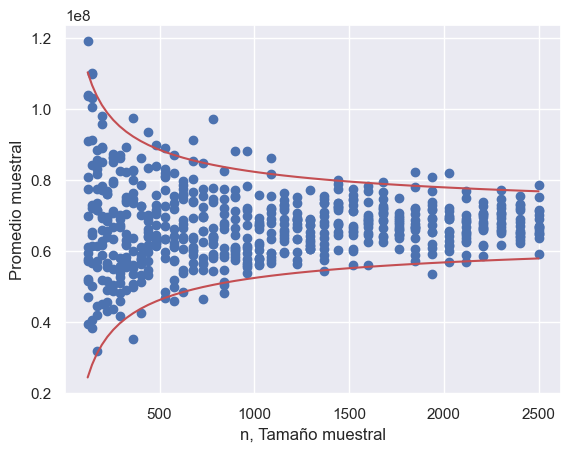

In [31]:
conf=0.95
alpha=1-conf
z_alpha=norm.ppf(1-alpha/2)
z_alpha
x,y=zip(*n_xbar)
plt.scatter(x,y)
plt.plot(n_ls,[prom+z_alpha*desvest/np.sqrt(n) for n in n_ls],c="r")
plt.plot(n_ls,[prom-z_alpha*desvest/np.sqrt(n) for n in n_ls],c="r")
plt.xlabel("n, Tamaño muestral")
plt.ylabel("Promedio muestral")
plt.show()

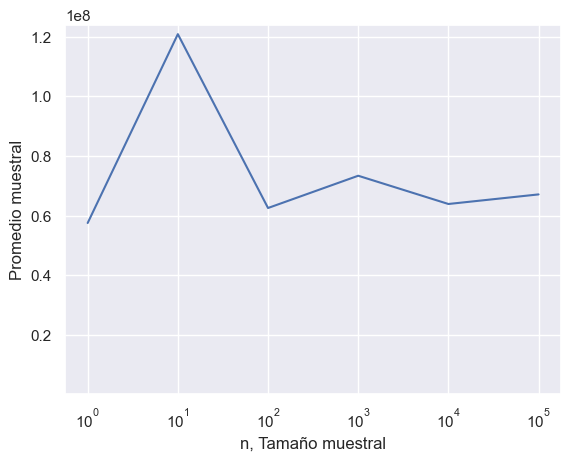

In [32]:
n_ls=[10**k for k in range(6)]
n_xbar=[[n,df.valor_contratoo.sample(n).mean()] for n in n_ls]
x,y=zip(*n_xbar)
plt.plot(x,y)
plt.xscale("log") #escala log en x
plt.ylim((50)) #ejec comienza desde cero
plt.xlabel("n, Tamaño muestral")
plt.ylabel("Promedio muestral")
plt.show()

## 2.2  SELECCIÓN TAMAÑO MUESTRA VARIABLE CUALITATIVA

In [33]:
freqs=df_original.sector.value_counts(normalize=True)
freqs

sector
Servicio Público                                      0.254560
No aplica/No pertenece                                0.162487
Salud y Protección Social                             0.150431
Educación Nacional                                    0.052891
Trabajo                                               0.046645
deportes                                              0.039126
Ambiente y Desarrollo Sostenible                      0.038064
Información Estadística                               0.029887
defensa                                               0.029400
Transporte                                            0.027933
Cultura                                               0.027529
agricultura                                           0.027120
Inclusión Social y Reconciliación                     0.025433
Vivienda, Ciudad y Territorio                         0.015533
Ley de Justicia                                       0.014579
Planeación                                      

In [34]:
z_alpha=norm.ppf(0.99)
dict(zip(freqs.index,[np.ceil(p*(1-p)*z_alpha**2/0.01**2) for p in freqs]))

{'Servicio Público': np.float64(10270.0),
 'No aplica/No pertenece': np.float64(7365.0),
 'Salud y Protección Social': np.float64(6917.0),
 'Educación Nacional': np.float64(2712.0),
 'Trabajo': np.float64(2407.0),
 'deportes': np.float64(2035.0),
 'Ambiente y Desarrollo Sostenible': np.float64(1982.0),
 'Información Estadística': np.float64(1570.0),
 'defensa': np.float64(1545.0),
 'Transporte': np.float64(1470.0),
 'Cultura': np.float64(1449.0),
 'agricultura': np.float64(1428.0),
 'Inclusión Social y Reconciliación': np.float64(1342.0),
 'Vivienda, Ciudad y Territorio': np.float64(828.0),
 'Ley de Justicia': np.float64(778.0),
 'Planeación': np.float64(632.0),
 'Hacienda y Crédito Público': np.float64(586.0),
 'Industria': np.float64(582.0),
 'Minas y Energía': np.float64(345.0),
 'Tecnologías de la Información y las Comunicaciones': np.float64(339.0),
 'interior': np.float64(240.0),
 'Presidencia de la República': np.float64(212.0),
 'Ciencia Tecnología': np.float64(144.0),
 'Relaci

# 3. ASOCIACIÓN ENTRE VARIABLES

## 3.1 ENTRE VARIABLES CUANTITATIVAS

In [35]:
corr=df.loc[:,cuantitativas].corr()
corr.style.background_gradient(cmap='coolwarm')

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
dias_espera_inicio,1.000000,0.018002,0.126481,0.095053
duracion_contrato,0.018002,1.000000,-0.092416,0.039576
dias_desde_primer_contrato,0.126481,-0.092416,1.000000,0.042106
valor_contratoo,0.095053,0.039576,0.042106,1.000000


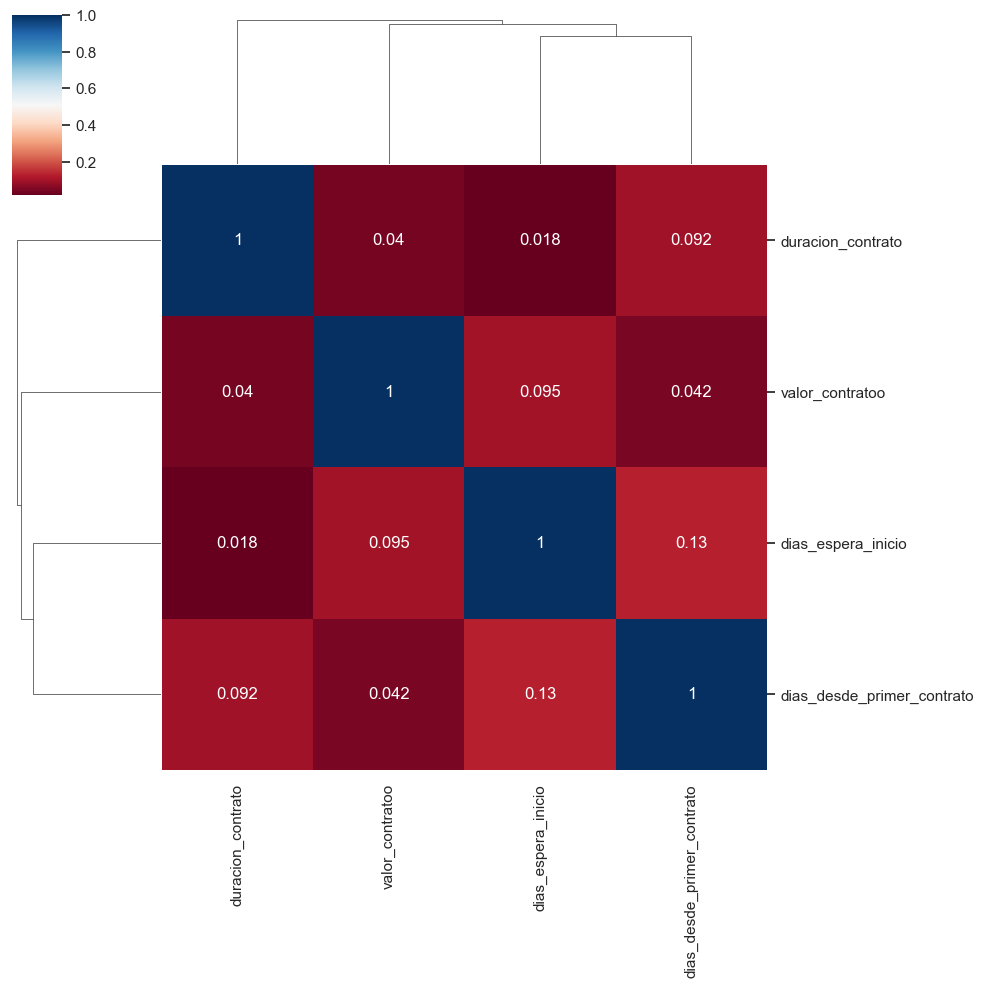

In [36]:
sns.clustermap(corr.abs(), method="complete", cmap='RdBu', annot=True)
plt.show()

In [37]:
corr=df.loc[:,cuantitativas].corr(method= 'spearman')
corr.style.background_gradient(cmap='coolwarm')

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
dias_espera_inicio,1.000000,0.116994,0.076670,0.213749
duracion_contrato,0.116994,1.000000,-0.524834,0.581025
dias_desde_primer_contrato,0.076670,-0.524834,1.000000,-0.272595
valor_contratoo,0.213749,0.581025,-0.272595,1.000000


## 3.2 ENTRE VARIABLES CATEGÓRICAS

In [38]:
categoricas = ['sector','rama','tipo_contrato','modalidad_contratacion']

x,y=df_original.rama,df_original.modalidad_contratacion
contingency_table = pd.crosstab(x,y)
contingency_table.style.background_gradient(cmap='coolwarm')

modalidad_contratacion,Concurso de méritos abierto,Contratación Directa (con ofertas),Contratación directa,Contratación régimen especial,Contratación régimen especial (con ofertas),Enajenación de bienes con sobre cerrado,Enajenación de bienes con subasta,Licitación Pública Acuerdo Marco de Precios,Licitación pública,Licitación pública Obra Publica,Mínima cuantía,Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,Selección Abreviada de Menor Cuantía,Selección abreviada subasta inversa
rama,,,,,,,,,,,,,,
Corporación Autónoma,235,833,90498,53010,1223,2,3,0,225,67,4932,11,897,912
Ejecutivo,1516,9122,580542,81732,5982,28,26,65,1524,432,40085,156,7655,7305
Judicial,28,218,2705,83,40,0,0,0,19,21,2142,0,222,499
Legislativo,3,10,6117,627,15,0,1,0,11,1,240,2,9,9


In [39]:
chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = chi2_contingency(contingency_table)
print("La estadístico chi2 es:",chi2_statistic)

La estadístico chi2 es: 72648.81755522116


In [40]:
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1 # min(rows-1, columns-1)
cramers_v = np.sqrt(chi2_statistic/ (n * min_dim))
print("Cramer's V:", cramers_v)

Cramer's V: 0.16384785095783058


In [41]:
vars_cat = ['sector', 'rama', 'tipo_contrato', 'modalidad_contratacion']
resultados = []

for v1, v2 in combinations(vars_cat, 2):
    tabla = pd.crosstab(df_original[v1], df_original[v2])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    resultados.append({'Variable 1': v1, 'Variable 2': v2, 'Cramers V': round(v, 4)})

pd.DataFrame(resultados).sort_values('Cramers V', ascending=False)

,Variable 1,Variable 2,Cramers V
5,tipo_contrato,modalidad_contratacion,0.5430
0,sector,rama,0.3649
2,sector,modalidad_contratacion,0.2083
4,rama,modalidad_contratacion,0.1638
3,rama,tipo_contrato,0.1309
1,sector,tipo_contrato,0.0804


## 3.3 ENTRE VARIABLES BINARIAS

In [42]:
corr_bin = df[binarias].corr()
corr_bin.style.background_gradient(cmap='coolwarm')

,centralizada,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,prorrogado,postconflicto
centralizada,1.000000,0.005406,0.003547,0.000894,-0.009354,-0.038389,-0.000720,0.039758,-0.014008,0.028634
grupo,0.005406,1.000000,0.049154,0.033102,0.102656,0.020904,0.005096,0.002889,0.003605,-0.002474
pime,0.003547,0.049154,1.000000,0.037974,0.261838,0.046676,0.019913,-0.038593,0.014431,-0.011082
pago_adelantado,0.000894,0.033102,0.037974,1.000000,0.029114,-0.004882,-0.000412,-0.003559,0.007376,0.002155
liquidacion,-0.009354,0.102656,0.261838,0.029114,1.000000,0.078873,0.015843,-0.022962,0.101219,-0.011561
obligacion_ambiente,-0.038389,0.020904,0.046676,-0.004882,0.078873,1.000000,0.046156,0.029549,0.017096,-0.008196
obligacion_postconsumo,-0.000720,0.005096,0.019913,-0.000412,0.015843,0.046156,1.000000,-0.006359,0.012751,0.000371
estado_bpin,0.039758,0.002889,-0.038593,-0.003559,-0.022962,0.029549,-0.006359,1.000000,-0.073735,-0.003744
prorrogado,-0.014008,0.003605,0.014431,0.007376,0.101219,0.017096,0.012751,-0.073735,1.000000,-0.015342
postconflicto,0.028634,-0.002474,-0.011082,0.002155,-0.011561,-0.008196,0.000371,-0.003744,-0.015342,1.000000


In [43]:
binarias

['centralizada',
 'grupo',
 'pime',
 'pago_adelantado',
 'liquidacion',
 'obligacion_ambiente',
 'obligacion_postconsumo',
 'estado_bpin',
 'prorrogado',
 'postconflicto']

In [44]:
corr_bin_spearman = df[binarias].corr(method='spearman')
corr_bin_spearman.style.background_gradient(cmap='coolwarm')

,centralizada,grupo,pime,pago_adelantado,liquidacion,obligacion_ambiente,obligacion_postconsumo,estado_bpin,prorrogado,postconflicto
centralizada,1.000000,0.005406,0.003547,0.000894,-0.009354,-0.038389,-0.000720,0.039758,-0.014008,0.028634
grupo,0.005406,1.000000,0.049154,0.033102,0.102656,0.020904,0.005096,0.002889,0.003605,-0.002474
pime,0.003547,0.049154,1.000000,0.037974,0.261838,0.046676,0.019913,-0.038593,0.014431,-0.011082
pago_adelantado,0.000894,0.033102,0.037974,1.000000,0.029114,-0.004882,-0.000412,-0.003559,0.007376,0.002155
liquidacion,-0.009354,0.102656,0.261838,0.029114,1.000000,0.078873,0.015843,-0.022962,0.101219,-0.011561
obligacion_ambiente,-0.038389,0.020904,0.046676,-0.004882,0.078873,1.000000,0.046156,0.029549,0.017096,-0.008196
obligacion_postconsumo,-0.000720,0.005096,0.019913,-0.000412,0.015843,0.046156,1.000000,-0.006359,0.012751,0.000371
estado_bpin,0.039758,0.002889,-0.038593,-0.003559,-0.022962,0.029549,-0.006359,1.000000,-0.073735,-0.003744
prorrogado,-0.014008,0.003605,0.014431,0.007376,0.101219,0.017096,0.012751,-0.073735,1.000000,-0.015342
postconflicto,0.028634,-0.002474,-0.011082,0.002155,-0.011561,-0.008196,0.000371,-0.003744,-0.015342,1.000000


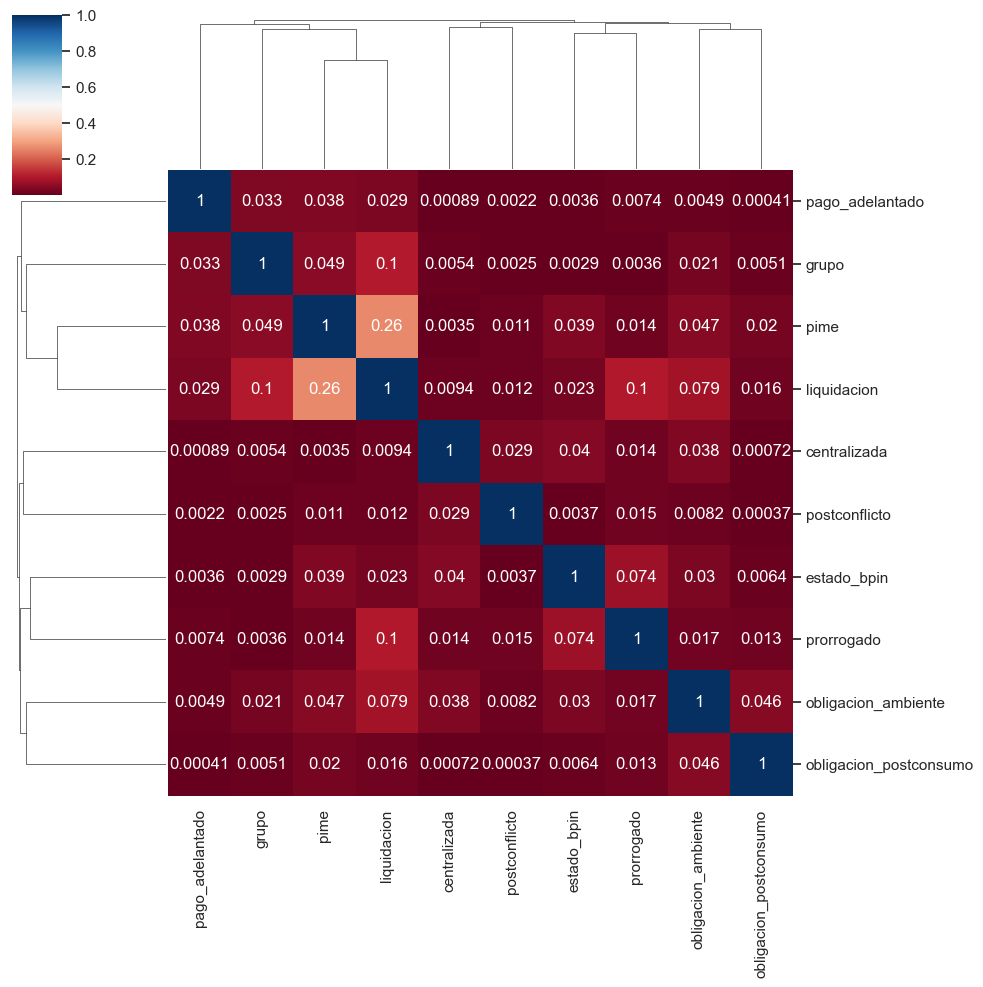

In [45]:
sns.clustermap(corr_bin.abs(), method="complete", cmap='RdBu', annot=True)
plt.show()

In [46]:
print(df[binarias].mean().sort_values())

obligacion_postconsumo    0.000191
pago_adelantado           0.000891
postconflicto             0.004097
grupo                     0.004465
obligacion_ambiente       0.026025
liquidacion               0.128158
pime                      0.142019
prorrogado                0.151504
estado_bpin               0.532097
centralizada              0.833380
dtype: float64


## 3.4 ENTRE BINARIAS Y CATEGORICAS

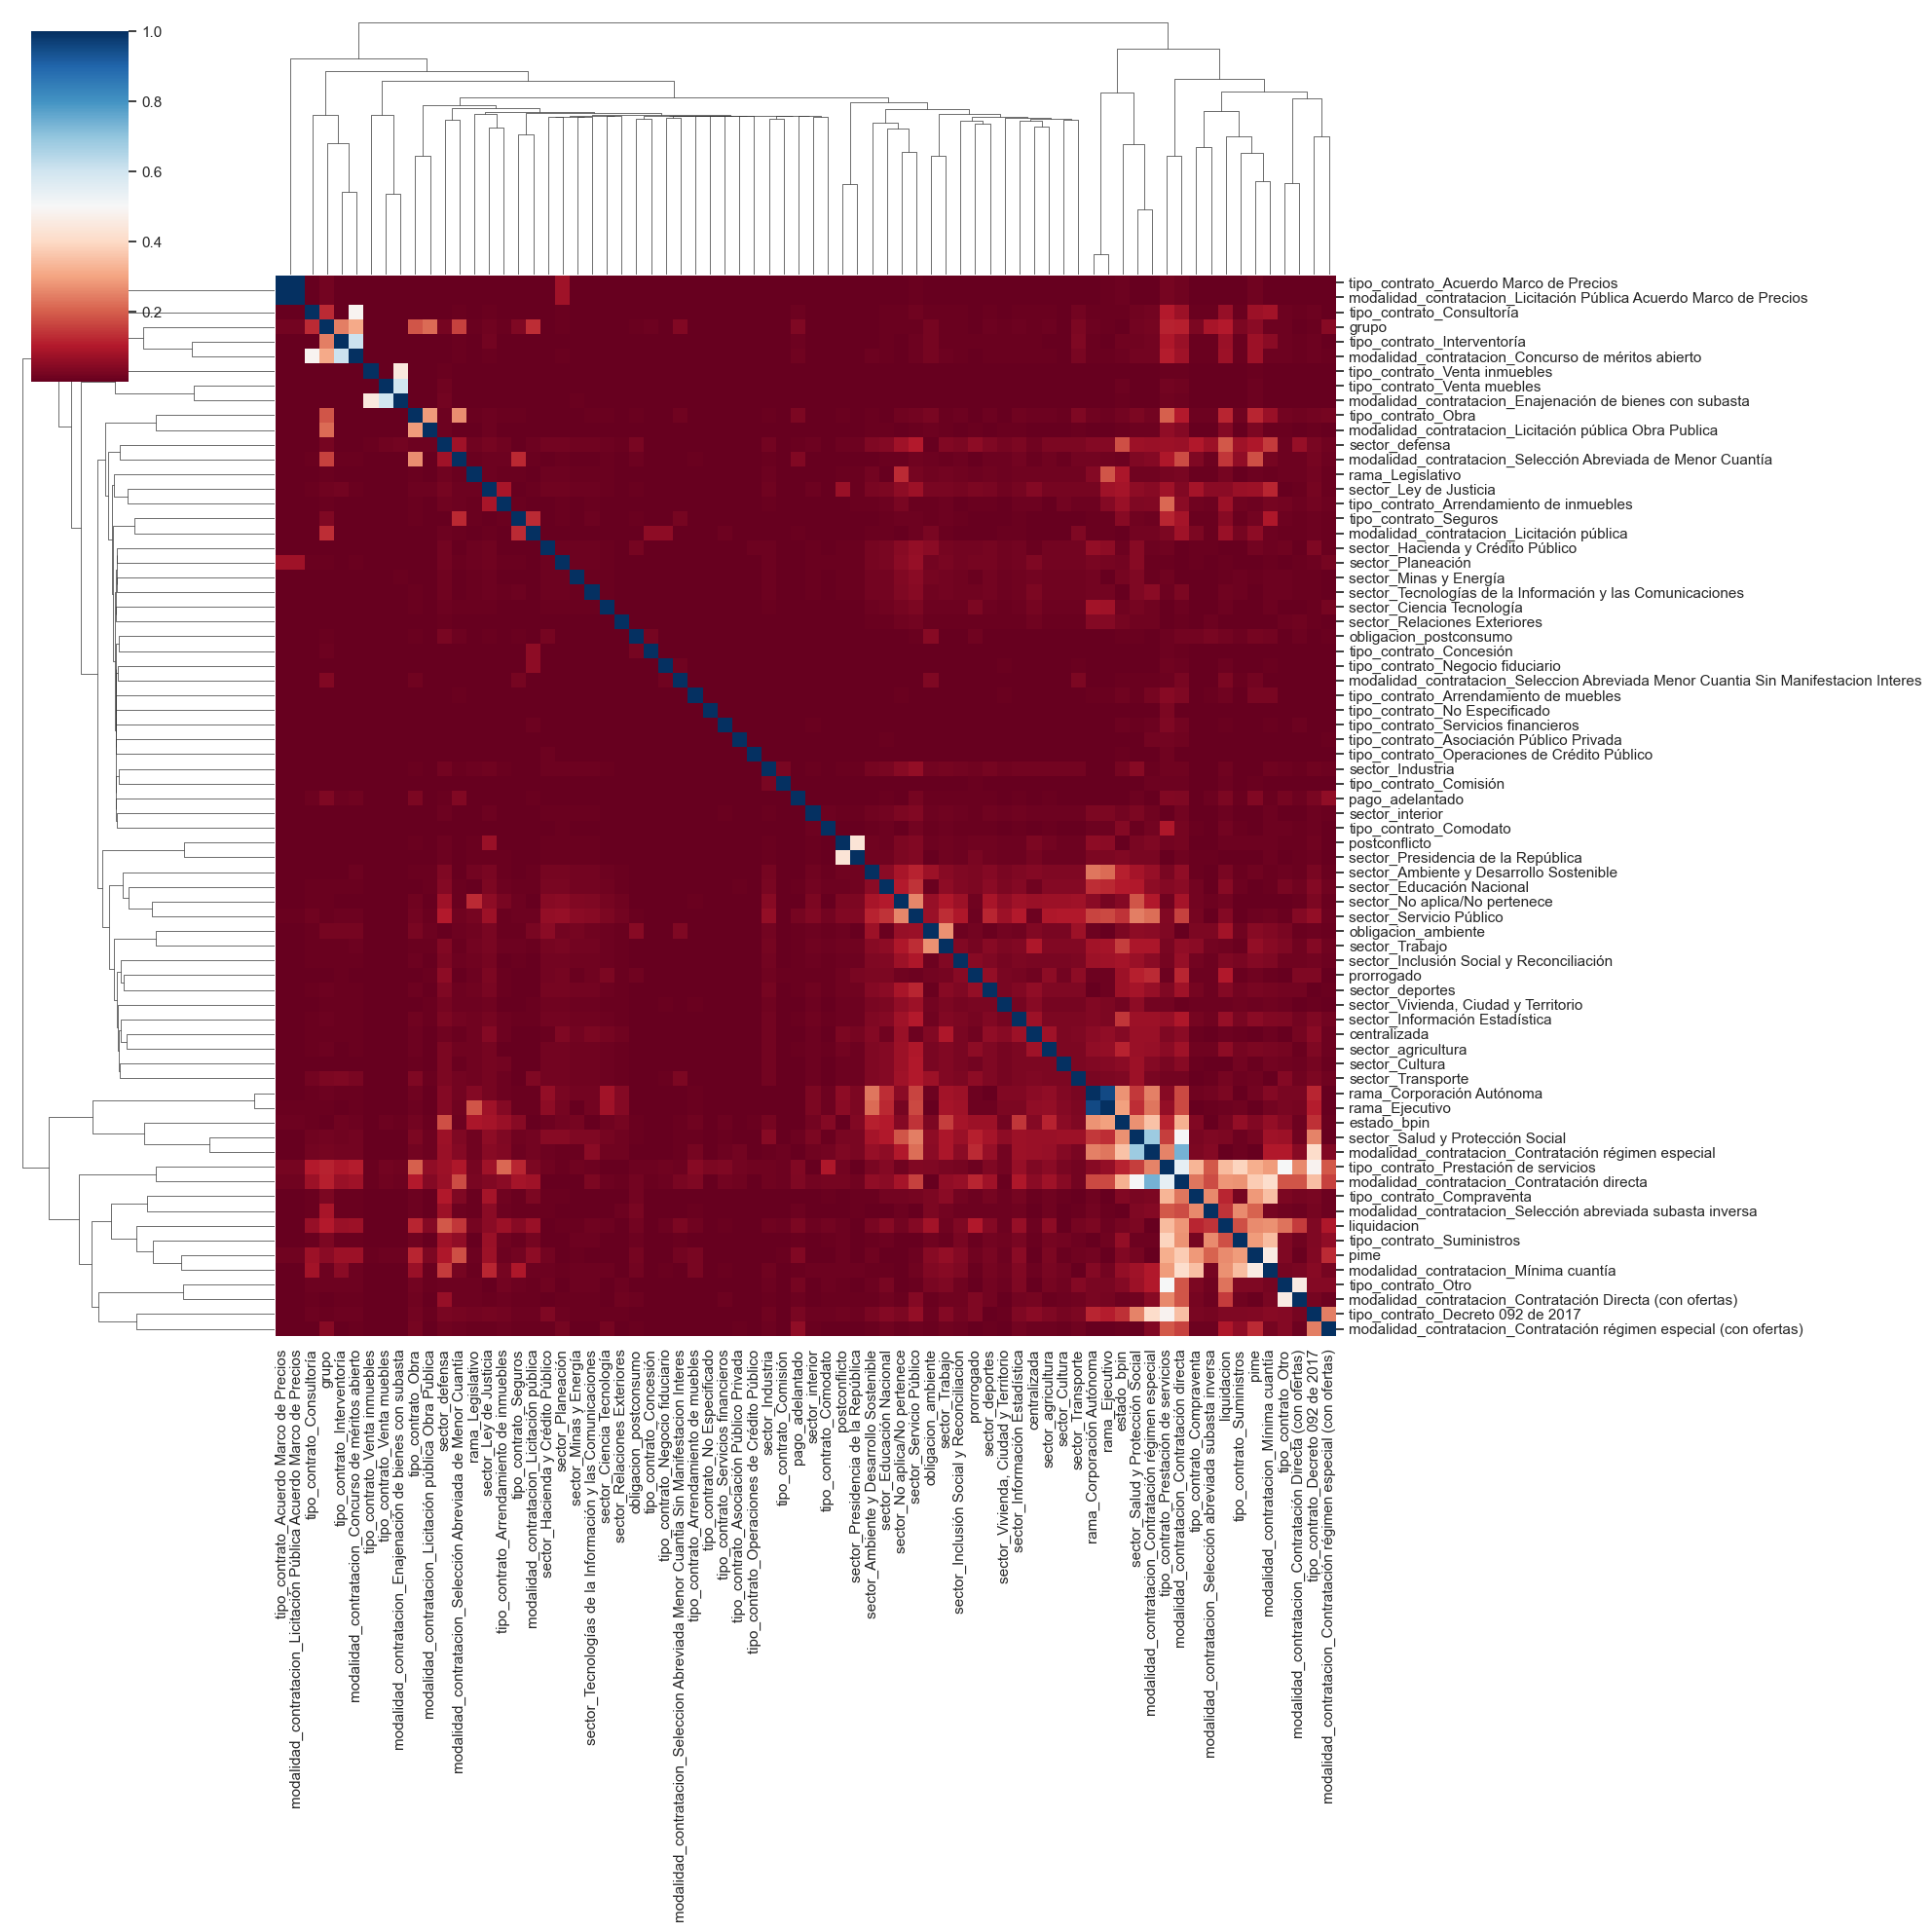

In [47]:
dummies_cat = [col for col in df.columns if any(col.startswith(v) for v in categoricas)]
cols_all = binarias + dummies_cat

corr_all = df[cols_all].corr().abs()
sns.clustermap(corr_all, method="complete", cmap='RdBu', annot=False, figsize=(20,20))
plt.show()

# 4. REDUCCIÓN DE DIMENSIONALIDAD

## 4.1 CUANTTIATIVAS

### 4.1.1 CORRELACIONES

In [48]:
cuantitativas = ['dias_espera_inicio','duracion_contrato','dias_desde_primer_contrato','valor_contratoo']

# Filtrado de datos como copia independiente
df_cuantitativas = df[cuantitativas].copy()

# Normalización de los datos
scaler = StandardScaler()
df_cuantitativas_scaled = scaler.fit_transform(df_cuantitativas)
df_cuantitativas = pd.DataFrame(df_cuantitativas_scaled, columns=cuantitativas)

df_cuantitativas

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
0,-0.341769,-0.228425,-0.842437,-0.220649
1,-0.341769,0.324498,1.641089,0.030032
2,0.480366,-0.244111,1.510867,-0.237194
3,-0.136235,0.044115,-1.158692,-0.211549
4,0.069298,-0.140192,1.017882,-0.222138
...,...,...,...,...
902035,-0.341769,-0.016667,-1.149390,-0.245467
902036,-0.341769,0.373516,-1.419136,-0.087086
902037,-0.033469,-0.285286,0.850453,-0.264990
902038,0.069298,0.130387,1.696899,-0.084672


In [49]:
df_cuantitativas.to_csv("pifcuantitativas.csv",index=False)

In [50]:
pd.DataFrame({"mean":df_cuantitativas.mean(),"std":df_cuantitativas.std()})

,mean,std
dias_espera_inicio,-1.701446e-17,1.000001
duracion_contrato,6.553718e-18,1.000001
dias_desde_primer_contrato,-1.474082e-15,1.000001
valor_contratoo,2.331611e-17,1.000001


In [51]:
corr=df_cuantitativas.corr()
corr.style.background_gradient(cmap='coolwarm')

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
dias_espera_inicio,1.000000,0.018002,0.126481,0.095053
duracion_contrato,0.018002,1.000000,-0.092416,0.039576
dias_desde_primer_contrato,0.126481,-0.092416,1.000000,0.042106
valor_contratoo,0.095053,0.039576,0.042106,1.000000


Archivo guardado como: correlograma_cuantitativas.png


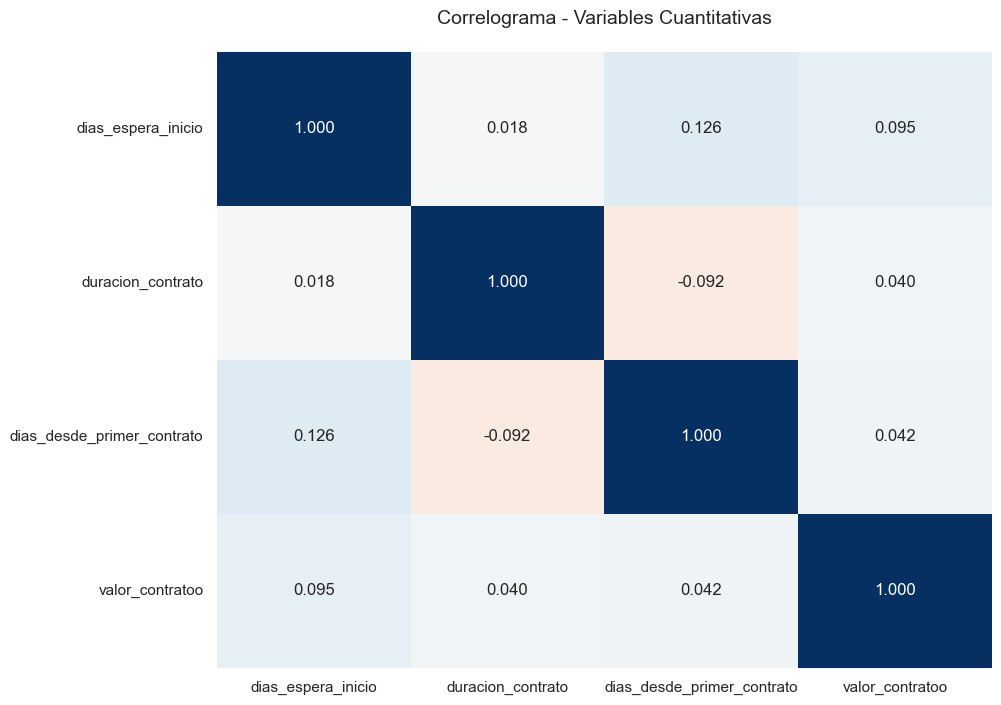

In [206]:
corr = df_cuantitativas.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, 
            ax=ax, cbar=False, fmt='.3f')
ax.set_title('Correlograma - Variables Cuantitativas', fontsize=14, pad=20)
plt.savefig('correlograma_cuantitativas.png', dpi=300, bbox_inches='tight')
print("Archivo guardado como: correlograma_cuantitativas.png")
plt.show()

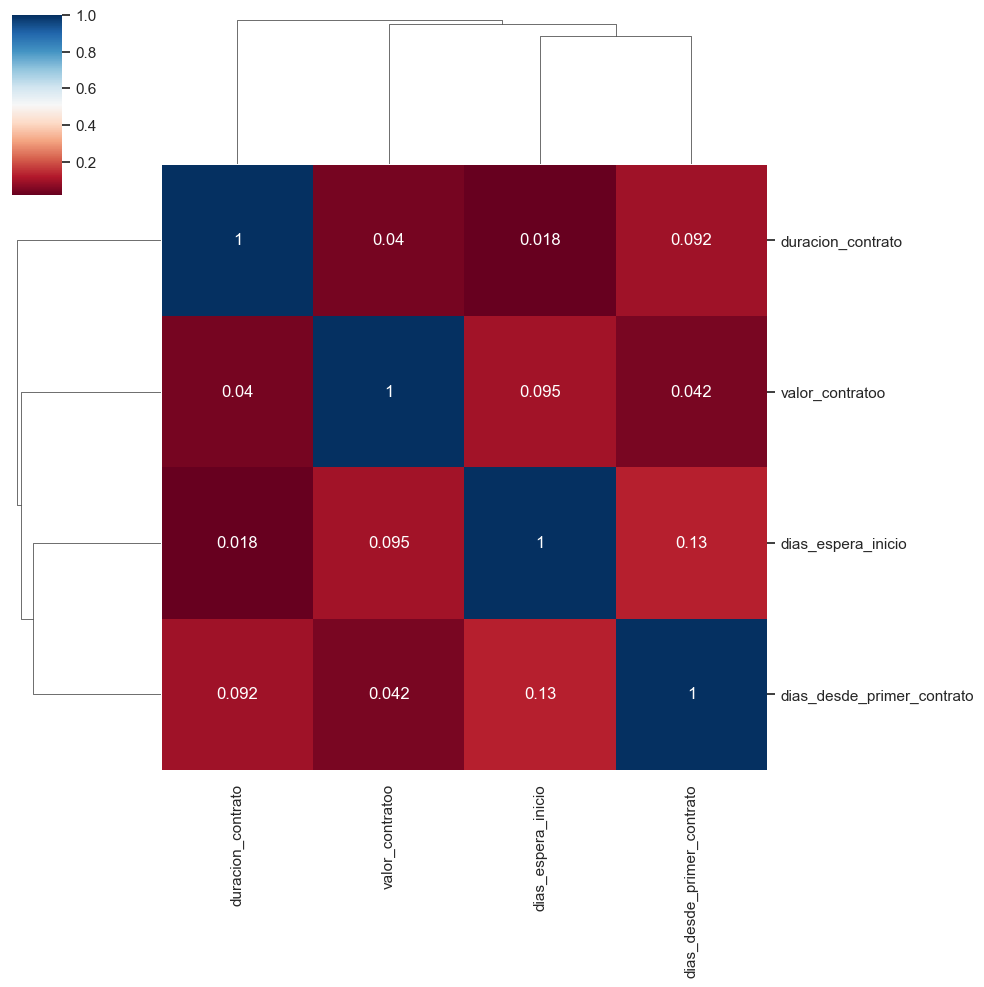

In [52]:
sns.clustermap(corr.abs(), method="complete", cmap='RdBu', annot=True)
plt.show()

### 4.1.2 PCA

In [53]:
# Aplicar PCA
pca = PCA()
pca_result = pca.fit_transform(df_cuantitativas_scaled)

In [54]:
df_pca=pd.DataFrame(pca_result)
df_pca.columns=[f'PC{i+1}' for i in range(df_pca.shape[1])]
df_pca.to_csv("df_pca.csv",index=None)

In [55]:
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print(f'Varianza explicada por cada componente: {explained_variance}')
print(f'Varianza total explicada: {explained_variance.cumsum()}')

Varianza explicada por cada componente: [0.29588522 0.26800806 0.22763524 0.20847148]
Varianza total explicada: [0.29588522 0.56389328 0.79152852 1.        ]


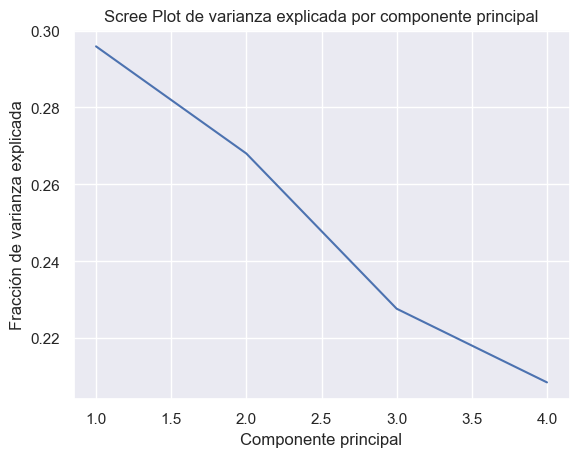

In [56]:
xx=np.arange(1, len(explained_variance)+1, step=1)
plt.plot(xx,explained_variance)
plt.title('Scree Plot de varianza explicada por componente principal')
plt.xlabel('Componente principal')
plt.ylabel('Fracción de varianza explicada')
plt.show()

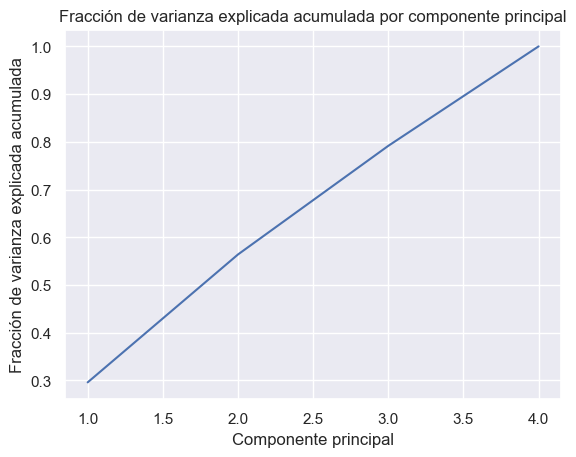

In [57]:
xx=np.arange(1, len(explained_variance)+1, step=1)
plt.plot(xx,explained_variance.cumsum())
plt.title('Fracción de varianza explicada acumulada por componente principal')
plt.xlabel('Componente principal')
plt.ylabel('Fracción de varianza explicada acumulada')
plt.show()

In [58]:
pesos=pd.DataFrame(pca.components_)
pesos.columns=df_cuantitativas.columns
pesos.index=[f'PC{i+1}' for i in range(pca_result.shape[1])]
pesos.style.background_gradient(cmap='coolwarm',axis=None)

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo
PC1,0.636372,-0.153465,0.616251,0.437851
PC2,0.201419,0.774062,-0.357690,0.481992
PC3,-0.440185,-0.445133,-0.193094,0.755519
PC4,-0.600581,0.423242,0.674542,0.071847


Archivo guardado como: pesos_pca.png


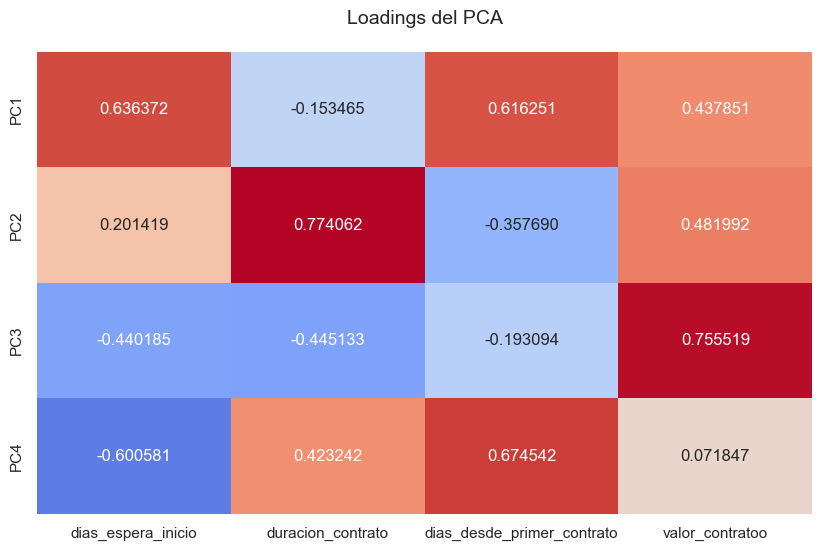

In [207]:
pesos = pd.DataFrame(pca.components_)
pesos.columns = df_cuantitativas.columns
pesos.index = [f'PC{i+1}' for i in range(pca_result.shape[1])]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pesos, annot=True, cmap='coolwarm', center=0, 
            ax=ax, cbar=False, fmt='.6f')
ax.set_title('Loadings del PCA', fontsize=14, pad=20)
plt.savefig('pesos_pca.png', dpi=300, bbox_inches='tight')
print("Archivo guardado como: pesos_pca.png")
plt.show()

  Componente  Varianza Explicada (%)  Varianza Acumulada (%)
0        PC1               29.588522               29.588522
1        PC2               26.800806               56.389328
2        PC3               22.763524               79.152852
3        PC4               20.847148              100.000000


In [59]:
# Convertir las componentes principales en un DataFrame
pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
pca_df

,PC1,PC2,PC3,PC4
0,-0.798202,-0.050673,0.248087,-0.475531
1,0.757182,-0.390183,-0.288198,1.451742
2,1.170372,-0.746949,-0.573733,0.610284
3,-0.900139,0.319195,0.104239,-0.696293
4,0.595622,-0.565715,-0.332477,0.569689
...,...,...,...,...
902035,-1.030726,0.211072,0.194347,-0.594742
902036,-1.187489,0.685922,0.192410,-0.600176
902037,0.430550,-0.659492,-0.222700,0.453983
902038,1.032733,-0.532889,-0.480176,1.152112


In [60]:
pca_df.corr().style.background_gradient(cmap='coolwarm',axis=None)

,PC1,PC2,PC3,PC4
PC1,1.000000,-0.000000,0.000000,-0.000000
PC2,-0.000000,1.000000,0.000000,-0.000000
PC3,0.000000,0.000000,1.000000,0.000000
PC4,-0.000000,-0.000000,0.000000,1.000000


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


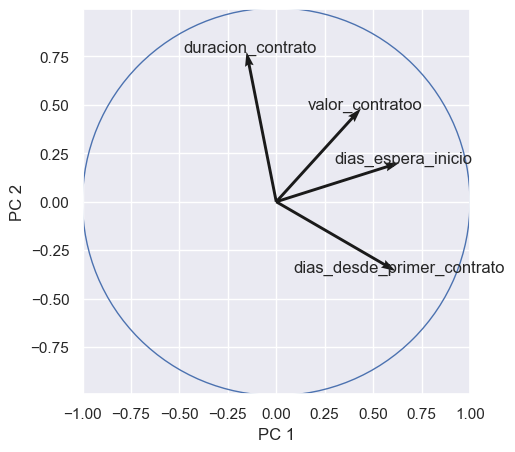

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


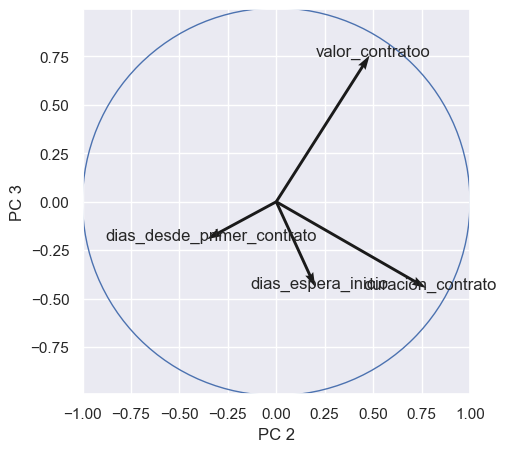

In [61]:
# Get the PCA components (loadings)
PCs = pca.components_

# Use quiver to generate the basic plot
fig = plt.figure(figsize=(5,5))
plt.quiver(np.zeros(PCs.shape[1]), np.zeros(PCs.shape[1]),
           PCs[0,:], PCs[1,:],
           angles='xy', scale_units='xy', scale=1)

# Add labels based on feature names (here just numbers)
feature_names = df_cuantitativas.columns

for i,j,z in zip(PCs[1,:]+0.02, PCs[0,:]+0.02, feature_names):
    plt.text(j, i, z, ha='center', va='center')

# Add unit circle
circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
plt.gca().add_artist(circle)

# Ensure correct aspect ratio and axis limits
plt.axis('equal')
plt.xlim([-1.0,1.0])
plt.ylim([-1.0,1.0])

# Label axes
plt.xlabel('PC 1')
plt.ylabel('PC 2')

# Done
plt.savefig('pca_pc1_pc2.pdf', bbox_inches='tight')
plt.savefig('pca_pc1_pc2.png', dpi=300, bbox_inches='tight') 
plt.show()

# Get the PCA components (loadings)
PCs = pca.components_

# Use quiver to generate the basic plot
fig = plt.figure(figsize=(5,5))
plt.quiver(np.zeros(PCs.shape[1]), np.zeros(PCs.shape[1]),
           PCs[1,:], PCs[2,:],
           angles='xy', scale_units='xy', scale=1)

# Add labels based on feature names (here just numbers)
feature_names = df_cuantitativas.columns

for i,j,z in zip(PCs[2,:]+0.02, PCs[1,:]+0.02, feature_names):
    plt.text(j, i, z, ha='center', va='center')

# Add unit circle
circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
plt.gca().add_artist(circle)

# Ensure correct aspect ratio and axis limits
plt.axis('equal')
plt.xlim([-1.0,1.0])
plt.ylim([-1.0,1.0])

# Label axes
plt.xlabel('PC 2')
plt.ylabel('PC 3')

# Done
plt.savefig('pca_pc2_pc3.pdf', bbox_inches='tight') 
plt.savefig('pca_pc2_pc3.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.2 CUALITATIVAS Y BINARIAS

### 4.2.1 CORRELACIONES

In [62]:
df_binarias = df[binarias].copy()
le = LabelEncoder()
for var in binarias:
    if df_binarias[var].dtype == object or str(df_binarias[var].dtype) == 'string':
        df_binarias[var] = le.fit_transform(df_binarias[var].astype(str)).astype(int)


In [63]:
# Dummies de categóricas 
dummies_cat = [col for col in df.columns if any(col.startswith(v + "_") for v in categoricas)]


In [64]:
df_binnom = pd.concat([df_binarias, df[dummies_cat]], axis=1)

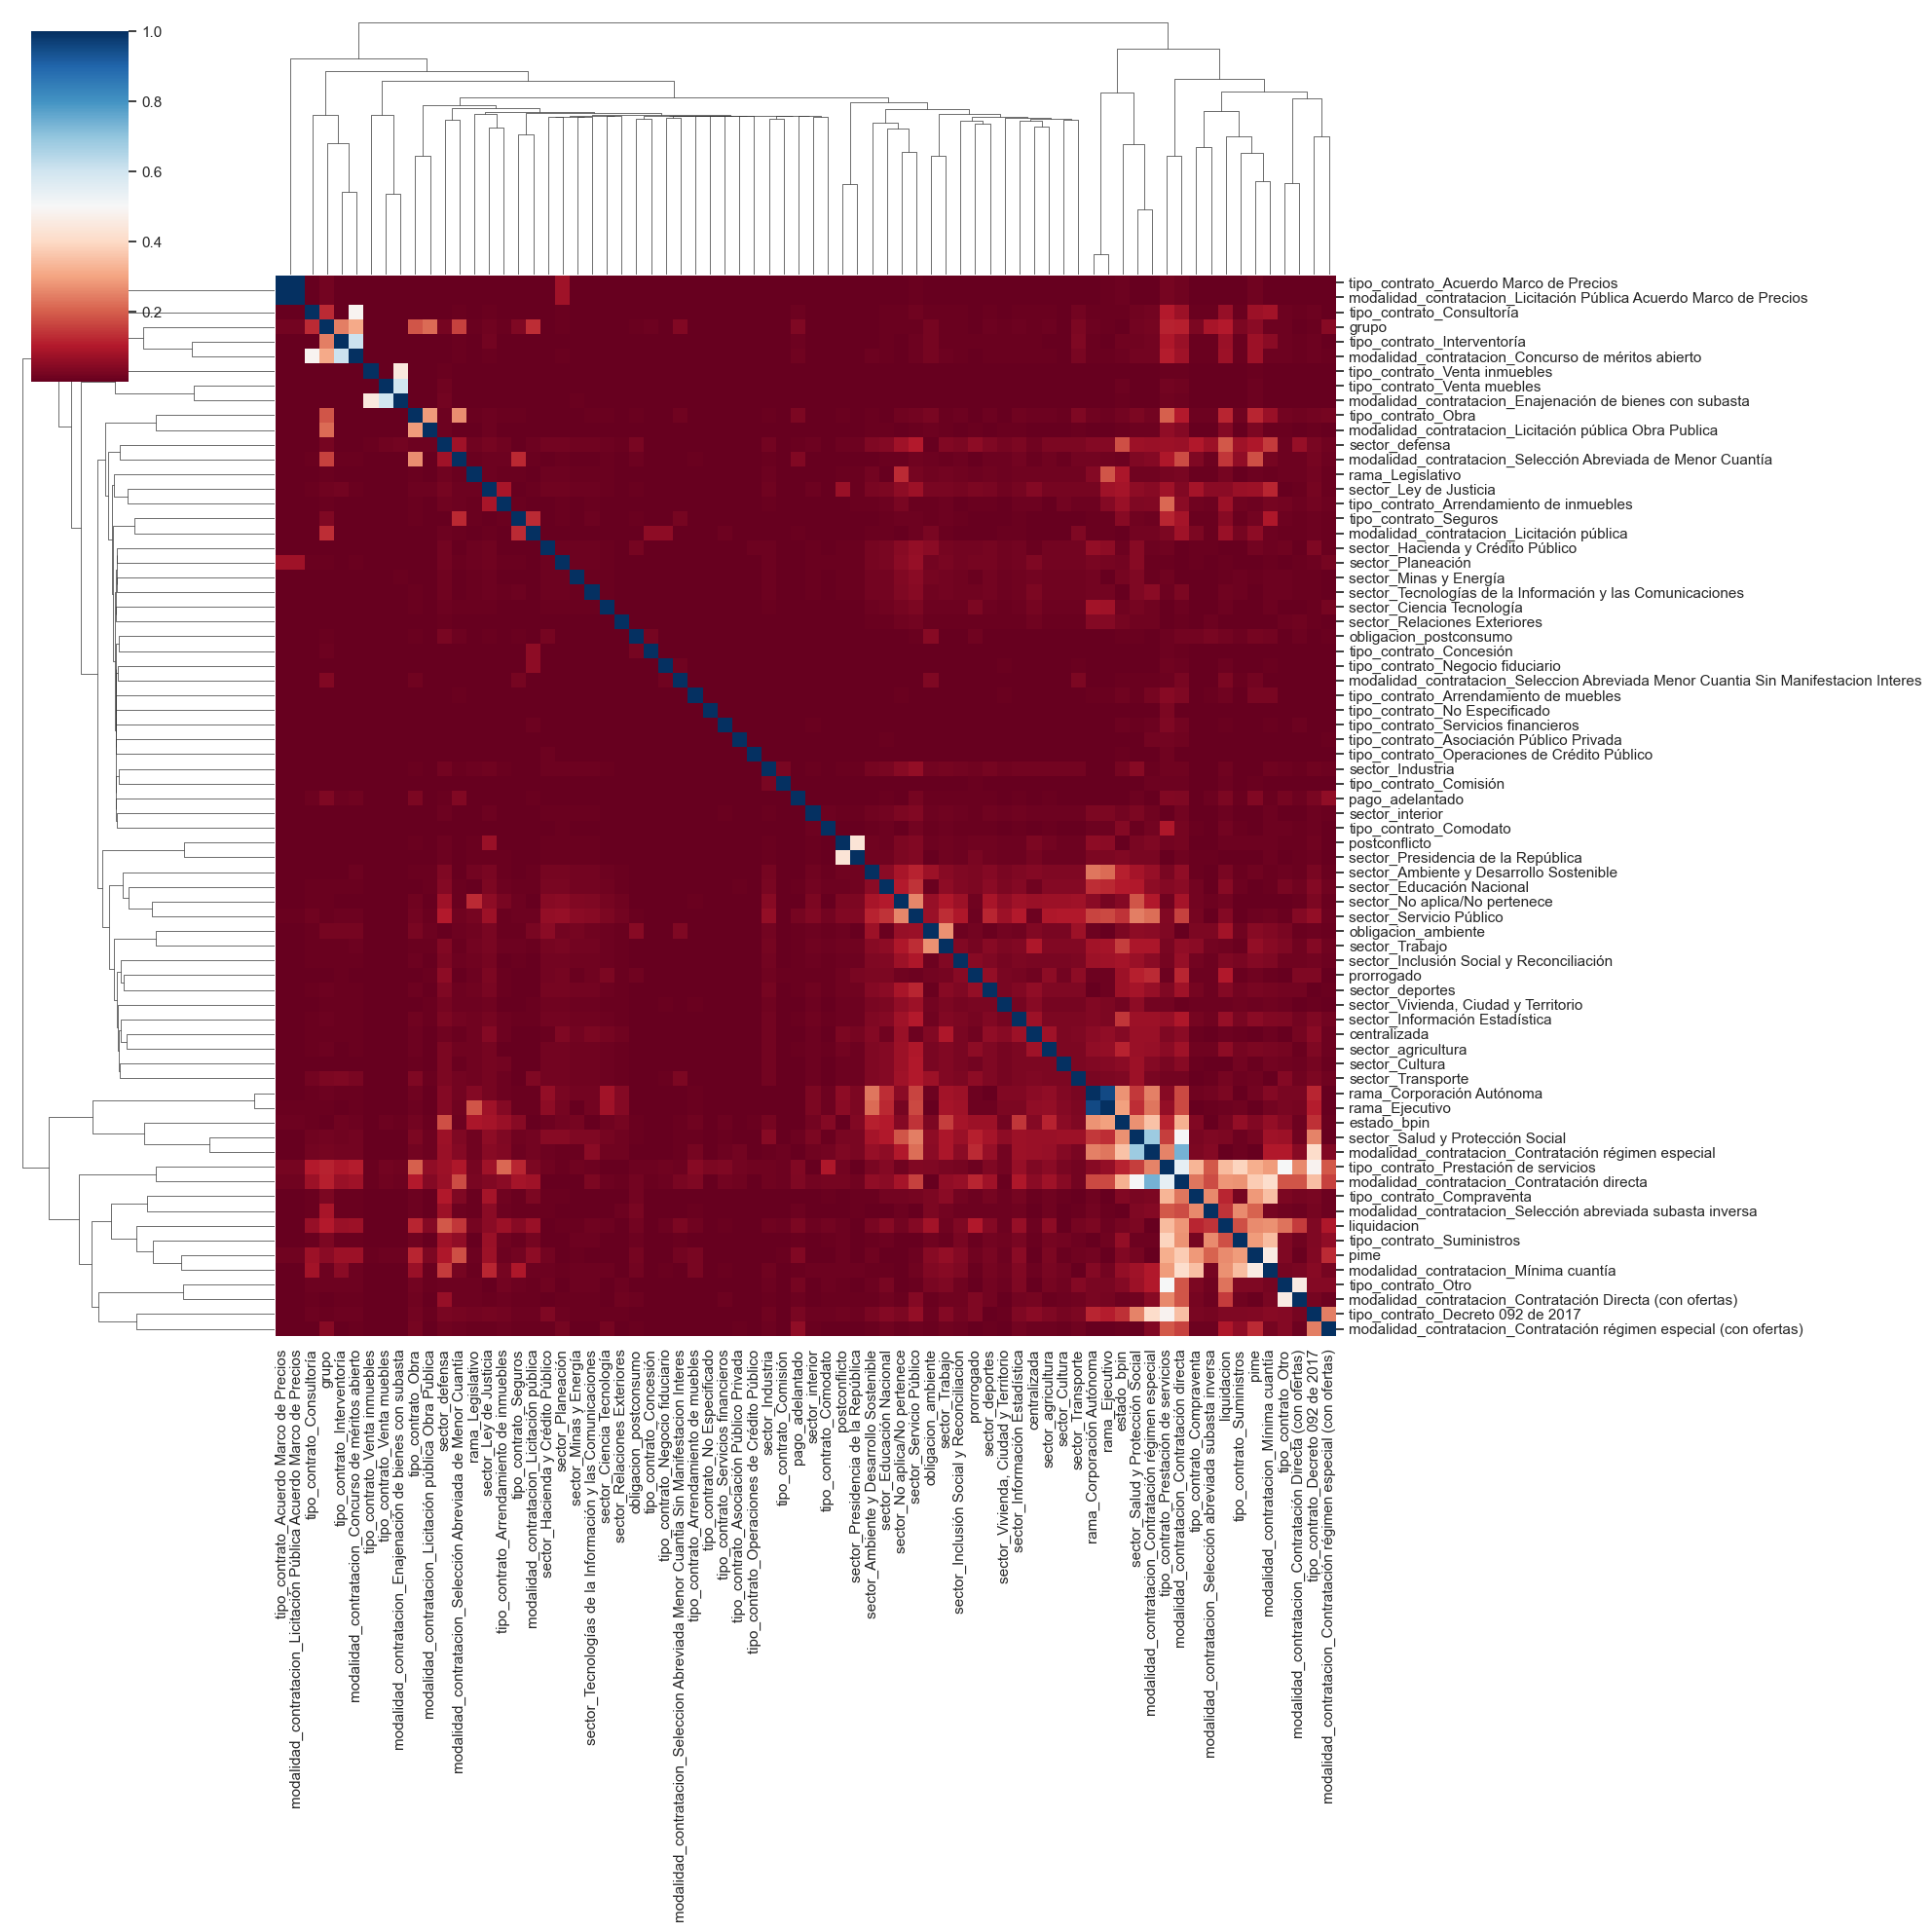

In [65]:
# Correlograma
corr_all = df_binnom.corr().abs()
sns.clustermap(corr_all, method="complete", cmap='RdBu', annot=False, figsize=(20, 20))
plt.show()

### 4.2.2 MCA

In [66]:
df_binnom.shape

(902040, 72)

In [67]:

nc = 35

mca = prince.MCA(
    n_components=nc,
    n_iter=5,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42,
    one_hot=False
)
mca.fit(df_binnom)
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.399,3.64%,3.64%
1,0.362,3.30%,6.93%
2,0.333,3.03%,9.96%
3,0.318,2.90%,12.86%
4,0.259,2.36%,15.23%
5,0.255,2.32%,17.55%
6,0.238,2.17%,19.72%
7,0.234,2.13%,21.85%
8,0.217,1.97%,23.83%


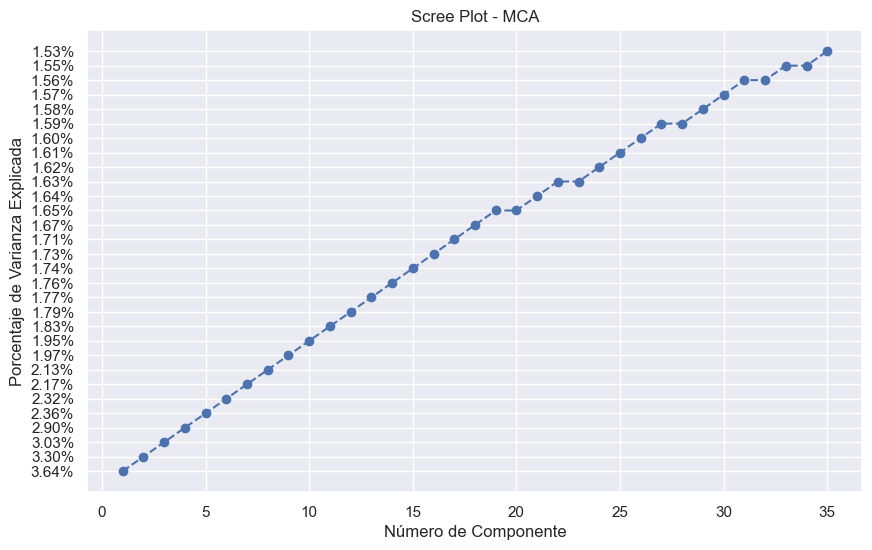

In [68]:
# Extraemos los porcentajes de varianza
varianza_expl = mca.eigenvalues_summary['% of variance']

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_expl) + 1), varianza_expl, marker='o', linestyle='--')
plt.title('Scree Plot - MCA')
plt.xlabel('Número de Componente')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.grid(True)
plt.show()

In [69]:
import joblib

# Guardas el modelo entrenado en un archivo
joblib.dump(mca, 'modelo_mca_corte1.pkl')

['modelo_mca_corte1.pkl']

In [70]:
mcas = pd.DataFrame(mca.row_coordinates(df_binnom))
mcas.columns = ["MCA" + str(i+1) for i in range(nc)]
mcas.head()

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,MCA9,MCA10,MCA11,MCA12,MCA13,MCA14,MCA15,MCA16,MCA17,MCA18,MCA19,MCA20,MCA21,MCA22,MCA23,MCA24,MCA25,MCA26,MCA27,MCA28,MCA29,MCA30,MCA31,MCA32,MCA33,MCA34,MCA35
0,-0.087243,-0.279376,0.002904,-0.000436,0.235491,-0.340149,-0.047159,0.477357,-0.177816,0.277512,-0.074876,-0.315313,0.186915,0.101324,0.142899,-0.386057,0.113263,0.248246,-0.398431,0.114960,-0.015102,0.123814,0.150369,0.267994,0.370767,-0.460128,-0.229904,-0.186400,0.154937,-0.421916,0.030496,-0.333929,-0.149168,-0.011196,0.791991
1,1.306779,-0.465614,0.009762,0.011992,0.012210,0.301119,-0.040259,-0.416913,-0.087272,-0.063678,-0.081101,-0.037164,0.410493,0.038529,0.153106,-0.670121,0.197044,-0.091313,-0.122506,0.067441,0.037468,0.123441,0.103232,-0.176263,0.088270,0.028507,-0.011265,0.048177,0.083869,0.014418,-0.000212,0.102255,-0.002530,0.102539,-0.097120
2,-0.502233,-0.314990,0.007575,0.003116,0.000818,0.132630,0.047187,-0.261014,-0.207582,0.041610,0.177906,0.090063,0.021362,0.113700,-0.266953,0.032131,0.100277,0.052154,0.042238,-0.037100,0.025141,-0.161671,-0.109760,0.206130,0.286944,-0.508839,-0.089393,0.386624,0.709633,0.170777,0.529664,-0.574655,-0.339869,0.541785,0.226969
3,-0.531330,-0.204608,0.002216,0.001427,0.030331,0.237774,-0.054642,-0.200019,-0.086114,0.097043,0.043099,0.141030,-0.039530,-0.100529,0.033629,0.135740,0.020994,-0.104528,0.047818,0.083975,0.060263,-0.168089,0.004015,-0.111276,0.087807,0.096733,0.240587,-0.090872,-0.024544,-0.268734,-0.019052,0.257605,-0.136304,0.251132,0.032059
4,0.361591,-0.398188,0.013161,0.014273,0.006662,0.116630,-0.009491,-0.255685,-0.049186,-0.044695,0.017441,0.026996,0.130616,-0.012428,0.057771,-0.233574,0.131405,-0.049927,-0.058936,-0.018121,-0.022017,-0.008384,0.088204,-0.081062,0.090714,-0.022738,0.021470,-0.011653,0.024491,0.061323,0.015070,0.054635,-0.034602,0.146798,-0.023628


In [71]:
# Scree plot
mca.scree_plot()
plt.show()

# Coordenadas de columnas (cómo se posicionan las categorías en los componentes)
mca.column_coordinates(df_binnom).style.background_gradient(cmap='coolwarm', axis=0)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34
centralizada,0.000750,-0.072407,0.008009,0.005514,0.004318,-0.036913,0.006055,0.012815,0.052653,-0.021725,0.029735,0.043466,-0.019170,-0.029739,-0.016021,0.021596,0.013752,-0.004394,0.029297,-0.003363,0.013196,-0.029636,0.002470,0.035875,0.000119,-0.021569,-0.011377,-0.015383,0.014165,0.012301,0.007378,-0.014998,-0.020892,0.008032,0.008678
grupo,0.312464,3.442325,0.232387,-0.244714,6.995684,-0.100992,0.272222,-0.047670,1.371427,2.242369,0.717969,-0.997581,-1.682560,-0.135436,0.006527,-1.369911,-0.150202,0.111909,-0.329221,-0.274089,-0.199025,-0.250821,0.679661,0.155142,0.493285,0.435575,-0.578265,0.313434,0.756453,0.555199,0.285620,-0.514411,0.992971,0.171577,0.168657
pime,0.359458,1.432513,-0.058950,-0.035364,-0.216582,-0.288788,-0.120234,-0.239876,-0.089258,-0.033197,-0.193362,0.055884,-0.257204,-0.043512,-0.043473,0.127768,-0.078080,0.022806,0.019326,-0.051107,-0.006974,-0.104715,-0.015710,0.040280,0.020294,-0.034258,0.034825,0.099405,-0.082690,-0.103171,0.065874,-0.050909,0.077769,-0.089794,0.075730
pago_adelantado,0.626297,1.491787,-0.060360,-0.118072,1.066992,0.675995,-0.117549,0.413661,0.940097,1.215421,-0.280323,0.556240,-2.817274,-1.572595,0.581030,1.583648,-0.751717,0.721257,0.064284,-0.233042,1.028064,-0.250966,-0.740638,-1.305045,0.215525,0.062394,2.047145,0.925040,-2.284415,-0.128380,-2.898288,-1.982975,0.677953,0.945709,1.094277
liquidacion,0.318563,1.250623,-0.089026,-0.070988,-0.036162,0.454685,0.038509,0.383526,0.157310,0.052272,0.151941,-0.077814,0.014190,-0.072108,0.062342,0.033770,-0.015437,-0.127437,0.019654,0.139609,0.054408,0.168278,-0.184829,-0.074475,-0.136523,0.128922,-0.010202,0.098250,-0.007179,0.090966,-0.107489,0.047570,-0.141143,-0.043855,-0.016548
obligacion_ambiente,-0.219059,0.537719,-0.058717,-0.044531,0.047095,-0.621338,-0.337796,0.801074,-1.376208,0.623765,-1.215486,-2.461741,0.315117,1.141788,0.810775,-0.099431,-0.298616,1.021937,-0.177948,-0.081499,0.014366,0.317618,-0.347110,0.174074,-0.154740,-0.123791,-0.033565,0.254215,-0.451134,0.050009,-0.225085,0.043299,-0.557839,-0.345683,0.121377
obligacion_postconsumo,0.277153,2.696913,-0.238507,-0.197683,-1.059761,-0.148358,0.012455,1.232001,-1.589098,0.721851,-1.171223,-2.828879,1.320387,1.446509,0.988269,-0.338775,-0.735965,-0.199629,-0.679103,2.135612,0.636996,2.330088,2.272178,1.061841,1.379738,0.716364,-0.637861,-1.490635,2.312164,-1.689208,-0.628354,-0.433527,-0.302544,-2.301425,-0.562544
estado_bpin,-0.421238,-0.094836,-0.002447,-0.007603,0.039258,0.187977,-0.038622,-0.118875,-0.145620,0.080889,-0.045486,-0.041788,-0.075699,0.063379,-0.070784,0.123561,-0.002575,0.013227,-0.029092,0.000490,-0.028935,-0.054631,0.000247,0.050024,0.047345,-0.047325,-0.013049,-0.006497,0.022740,-0.055546,0.045968,-0.064319,0.050261,-0.072045,0.027901
prorrogado,0.365847,0.006550,-0.004671,-0.005176,-0.022462,0.164178,-0.127602,0.006842,0.009299,-0.089159,-0.135820,-0.075254,0.376579,-0.005028,0.206088,-0.609993,0.146572,-0.095007,-0.046043,0.196801,0.196589,0.240755,-0.092247,-0.229664,-0.076748,0.153707,-0.053053,0.125933,0.109392,-0.082617,-0.102359,0.086753,0.011398,-0.065283,-0.130322
postconflicto,0.063883,-0.147010,-0.022048,-0.026827,-0.679995,-1.829994,11.349839,-0.334122,-0.374719,0.850427,-0.855770,-0.169030,-0.231694,-0.000892,0.101180,0.109122,-0.051039,-0.002789,-0.015160,0.181889,-0.123907,-0.155574,0.090451,-0.072372,0.116095,0.211073,-0.050496,-0.225039,-0.007698,-0.088963,-0.002152,-0.093314,0.310512,-0.257264,-0.174528


In [72]:
contribs = mca.column_contributions_
print(contribs.index.tolist()[:10])  # ver cómo se llaman realmente las columnas

['centralizada', 'grupo', 'pime', 'pago_adelantado', 'liquidacion', 'obligacion_ambiente', 'obligacion_postconsumo', 'estado_bpin', 'prorrogado', 'postconflicto']


In [73]:
contribs = mca.column_contributions_
contrib_por_variable = {}
for var in binarias + categoricas:
    
    cols_var = [c for c in contribs.index if c == var or c.startswith(var + "_")]
    if cols_var:
        contrib_por_variable[var] = contribs.loc[cols_var].values.sum()

contrib_df = pd.Series(contrib_por_variable).sort_values(ascending=False)
print(contrib_df)

sector                    15.860421
tipo_contrato             12.347401
modalidad_contratacion     3.960407
rama                       1.172603
postconflicto              0.399504
obligacion_ambiente        0.347933
grupo                      0.237800
pime                       0.194743
liquidacion                0.165481
prorrogado                 0.142588
estado_bpin                0.106198
pago_adelantado            0.041009
centralizada               0.013074
obligacion_postconsumo     0.010840
dtype: float64


Archivo guardado como: contribucion_mca.png


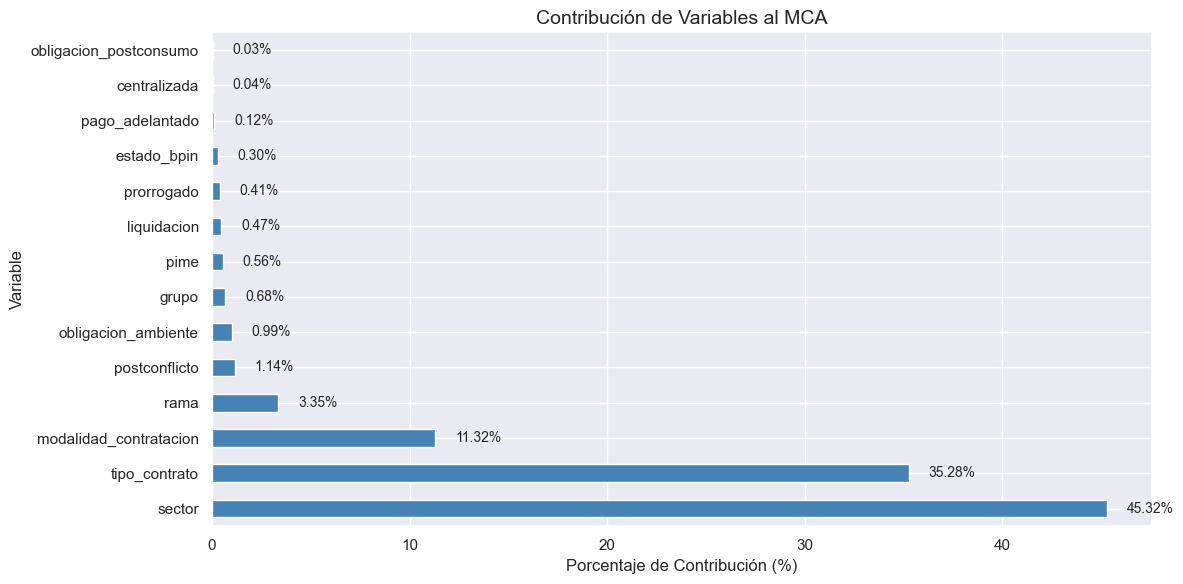

In [208]:
# Calcular el porcentaje relativo
contrib_pct = (contrib_df / contrib_df.sum()) * 100

# Crear gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
contrib_pct.plot(kind='barh', ax=ax, color='steelblue')

ax.set_xlabel('Porcentaje de Contribución (%)', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.set_title('Contribución de Variables al MCA', fontsize=14)

# Añadir valores en las barras
for i, v in enumerate(contrib_pct):
    ax.text(v + 1, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('contribucion_mca.png', dpi=300, bbox_inches='tight')
print("Archivo guardado como: contribucion_mca.png")
plt.show()

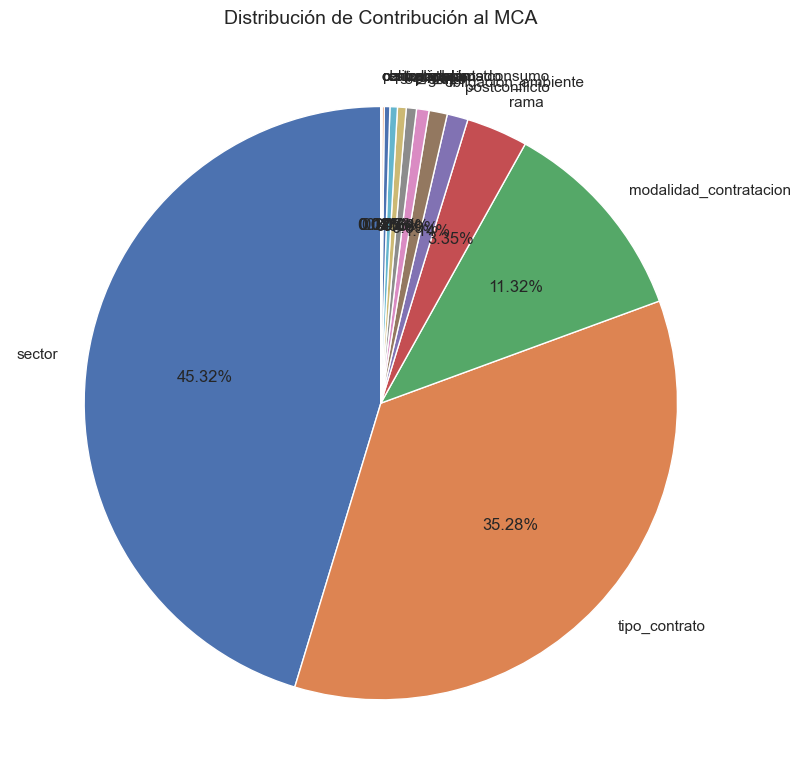

In [199]:
fig, ax = plt.subplots(figsize=(10, 8))
contrib_pct.plot(kind='pie', ax=ax, autopct='%1.2f%%', startangle=90)

ax.set_ylabel('')
ax.set_title('Distribución de Contribución al MCA', fontsize=14)
plt.tight_layout()
plt.show()

In [74]:
# Extraer coordenadas finales para uso en modelado
nt = 35
mcas = pd.DataFrame(mca.row_coordinates(df_binnom)).iloc[:, :nt]
mcas.columns = ["MCA" + str(i+1) for i in range(nt)]
mcas

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,MCA9,MCA10,MCA11,MCA12,MCA13,MCA14,MCA15,MCA16,MCA17,MCA18,MCA19,MCA20,MCA21,MCA22,MCA23,MCA24,MCA25,MCA26,MCA27,MCA28,MCA29,MCA30,MCA31,MCA32,MCA33,MCA34,MCA35
0,-0.087243,-0.279376,0.002904,-0.000436,0.235491,-0.340149,-0.047159,0.477357,-0.177816,0.277512,-0.074876,-0.315313,0.186915,0.101324,0.142899,-0.386057,0.113263,0.248246,-0.398431,0.114960,-0.015102,0.123814,0.150369,0.267994,0.370767,-0.460128,-0.229904,-0.186400,0.154937,-0.421916,0.030496,-0.333929,-0.149168,-0.011196,0.791991
1,1.306779,-0.465614,0.009762,0.011992,0.012210,0.301119,-0.040259,-0.416913,-0.087272,-0.063678,-0.081101,-0.037164,0.410493,0.038529,0.153106,-0.670121,0.197044,-0.091313,-0.122506,0.067441,0.037468,0.123441,0.103232,-0.176263,0.088270,0.028507,-0.011265,0.048177,0.083869,0.014418,-0.000212,0.102255,-0.002530,0.102539,-0.097120
2,-0.502233,-0.314990,0.007575,0.003116,0.000818,0.132630,0.047187,-0.261014,-0.207582,0.041610,0.177906,0.090063,0.021362,0.113700,-0.266953,0.032131,0.100277,0.052154,0.042238,-0.037100,0.025141,-0.161671,-0.109760,0.206130,0.286944,-0.508839,-0.089393,0.386624,0.709633,0.170777,0.529664,-0.574655,-0.339869,0.541785,0.226969
3,-0.531330,-0.204608,0.002216,0.001427,0.030331,0.237774,-0.054642,-0.200019,-0.086114,0.097043,0.043099,0.141030,-0.039530,-0.100529,0.033629,0.135740,0.020994,-0.104528,0.047818,0.083975,0.060263,-0.168089,0.004015,-0.111276,0.087807,0.096733,0.240587,-0.090872,-0.024544,-0.268734,-0.019052,0.257605,-0.136304,0.251132,0.032059
4,0.361591,-0.398188,0.013161,0.014273,0.006662,0.116630,-0.009491,-0.255685,-0.049186,-0.044695,0.017441,0.026996,0.130616,-0.012428,0.057771,-0.233574,0.131405,-0.049927,-0.058936,-0.018121,-0.022017,-0.008384,0.088204,-0.081062,0.090714,-0.022738,0.021470,-0.011653,0.024491,0.061323,0.015070,0.054635,-0.034602,0.146798,-0.023628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902035,-0.394254,-0.212255,0.004802,0.008966,0.014695,0.055279,0.031061,-0.150395,0.350054,-0.212956,-0.072093,-0.096885,-0.076081,0.054575,-0.031999,0.073306,-0.015004,-0.070679,-0.002373,0.019041,0.030519,-0.022822,-0.018656,0.040309,-0.009440,-0.013102,-0.039802,0.009484,-0.004153,0.031214,0.019796,-0.098766,0.004269,-0.056493,-0.073795
902036,-0.221898,-0.312410,0.009070,0.016717,0.106234,-0.870682,-0.151420,1.071005,-0.166551,0.131031,-0.075751,-0.450178,0.392615,-0.051457,0.197589,0.339919,-0.191880,-0.774393,-0.028576,0.005322,0.173590,-0.534415,0.291003,-0.330320,0.168094,0.142343,0.378856,0.056992,-0.235665,0.164560,-0.000902,0.152721,0.086753,0.357646,0.024024
902037,-0.442577,-0.190577,0.004161,0.002818,0.026690,0.185955,-0.043467,-0.162269,-0.052908,0.073032,0.046968,0.133886,-0.040200,-0.095047,0.021912,0.121379,0.022787,-0.088817,0.051312,0.068660,0.055401,-0.151738,0.004320,-0.078546,0.073219,0.072032,0.195943,-0.081875,-0.014780,-0.219008,-0.012906,0.208623,-0.122016,0.212520,0.030249
902038,0.022166,1.014079,-0.063933,-0.062290,0.134808,0.932813,0.042793,0.496702,0.652064,1.110897,0.153618,-0.166297,-0.330740,-0.176746,-0.193007,-0.117246,-0.100542,0.068351,0.087350,-0.140922,-0.163372,-0.143131,0.013498,-0.166965,0.018394,-0.224486,0.125030,-0.243148,-0.231185,-0.182553,-0.026401,-0.131772,-0.045531,-0.036405,-0.215649


In [75]:
# Eliminar todas las columnas MCA existentes antes de agregar las nuevas
cols_mca_existentes = [col for col in df.columns if col.startswith('MCA')]
df = df.drop(columns=cols_mca_existentes)

# También eliminar las dummies categóricas si aún están
dummies_cat = [col for col in df.columns if any(col.startswith(v + "_") for v in categoricas)]
df = df.drop(columns=dummies_cat, errors='ignore')

# Agregar componentes MCA limpios
mcas.index = df.index
df = pd.concat([df, mcas], axis=1)
     

In [76]:
mca_vars_actual = mca.column_contributions_.index
yy = mca.column_contributions_.values.sum(axis=1)


orden = yy.argsort()[::-1]
mca_vars_sorted = mca_vars_actual[orden]
yy_sorted = yy[orden]

fig = px.bar(
    x=yy_sorted, 
    y=mca_vars_sorted,
    orientation='h', 
    color=yy_sorted,
    color_continuous_scale='Blues'
)
fig.update_layout(
    title='Contribución total de cada variable al MCA',
    xaxis_title='Suma de contribuciones',
    yaxis_title='',
    height=1200,  
    coloraxis_showscale=False,
    yaxis=dict(tickfont=dict(size=10))
)
fig.show()


In [77]:
cols_finales = cuantitativas + ["MCA" + str(i+1) for i in range(nc)]
df_final = df[cols_finales].copy()
df_final.to_csv('df_final.csv', index=False)
df_final.head()

,dias_espera_inicio,duracion_contrato,dias_desde_primer_contrato,valor_contratoo,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7,MCA8,MCA9,MCA10,MCA11,MCA12,MCA13,MCA14,MCA15,MCA16,MCA17,MCA18,MCA19,MCA20,MCA21,MCA22,MCA23,MCA24,MCA25,MCA26,MCA27,MCA28,MCA29,MCA30,MCA31,MCA32,MCA33,MCA34,MCA35
0,0,42,2854,14000000,-0.087243,-0.279376,0.002904,-0.000436,0.235491,-0.340149,-0.047159,0.477357,-0.177816,0.277512,-0.074876,-0.315313,0.186915,0.101324,0.142899,-0.386057,0.113263,0.248246,-0.398431,0.114960,-0.015102,0.123814,0.150369,0.267994,0.370767,-0.460128,-0.229904,-0.186400,0.154937,-0.421916,0.030496,-0.333929,-0.149168,-0.011196,0.791991
1,0,324,3121,74604735,1.306779,-0.465614,0.009762,0.011992,0.012210,0.301119,-0.040259,-0.416913,-0.087272,-0.063678,-0.081101,-0.037164,0.410493,0.038529,0.153106,-0.670121,0.197044,-0.091313,-0.122506,0.067441,0.037468,0.123441,0.103232,-0.176263,0.088270,0.028507,-0.011265,0.048177,0.083869,0.014418,-0.000212,0.102255,-0.002530,0.102539,-0.097120
2,8,34,3107,10000000,-0.502233,-0.314990,0.007575,0.003116,0.000818,0.132630,0.047187,-0.261014,-0.207582,0.041610,0.177906,0.090063,0.021362,0.113700,-0.266953,0.032131,0.100277,0.052154,0.042238,-0.037100,0.025141,-0.161671,-0.109760,0.206130,0.286944,-0.508839,-0.089393,0.386624,0.709633,0.170777,0.529664,-0.574655,-0.339869,0.541785,0.226969
3,2,181,2820,16200000,-0.531330,-0.204608,0.002216,0.001427,0.030331,0.237774,-0.054642,-0.200019,-0.086114,0.097043,0.043099,0.141030,-0.039530,-0.100529,0.033629,0.135740,0.020994,-0.104528,0.047818,0.083975,0.060263,-0.168089,0.004015,-0.111276,0.087807,0.096733,0.240587,-0.090872,-0.024544,-0.268734,-0.019052,0.257605,-0.136304,0.251132,0.032059
4,4,87,3054,13639878,0.361591,-0.398188,0.013161,0.014273,0.006662,0.116630,-0.009491,-0.255685,-0.049186,-0.044695,0.017441,0.026996,0.130616,-0.012428,0.057771,-0.233574,0.131405,-0.049927,-0.058936,-0.018121,-0.022017,-0.008384,0.088204,-0.081062,0.090714,-0.022738,0.021470,-0.011653,0.024491,0.061323,0.015070,0.054635,-0.034602,0.146798,-0.023628
